# Sanity check for esnuelML model

In [ ]:
from mod_for_analysis import load_csv, load_pred_value, calculate_stats

# MCA
df = load_csv(f'./results/mecap_ref_mca_layer_0/predictions.csv')
df['esnuelML'] = load_pred_value('./references/esnuelML_nuc_predicted_values.csv')
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['esnuelML'])
print(f'MCA for test:\nr={r:.4f}, r2={r2:.4f}, rmse={rmse:.4f}')

# MAA
df = load_csv(f'./results/mecap_ref_maa_layer_0/predictions.csv')
df['esnuelML'] = load_pred_value('./references/esnuelML_elec_predicted_values.csv')
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['esnuelML'])
print(f'MAA for test:\nr={r:.4f}, r2={r2:.4f}, rmse={rmse:.4f}')


MCA for test:
r=0.9709, r2=0.9426, rmse=17.4489
MAA for test:
r=0.9516, r2=0.9055, rmse=22.0792


# Statistical metrics

## Analysis on Uni-Mol1-MeCAP models 

In [ ]:
'''Statistical table for Reference split'''
import pandas as pd
from mod_for_analysis import load_csv, calculate_stats, extract_best_epoch

mca_dict, maa_dict = {}, {}

for layer in range(3):
    # MCA
    be_ = extract_best_epoch(f'./results/mecap_ref_mca_layer_{layer}/train.log')
    df = load_csv(f'./results/mecap_ref_mca_layer_{layer}/predictions.csv')
    df_test = df[df['Set']=='Test']
    r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
    mca_dict[f'UniMol1_MCA_layer{layer}'] = {
        'best_epoch': be_,
        'r2': r2,
        'r': r,
        'rmse': rmse,
    }

    # MAA
    be_ = extract_best_epoch(f'./results/mecap_ref_maa_layer_{layer}/train.log')
    df = load_csv(f'./results/mecap_ref_maa_layer_{layer}/predictions.csv')
    df_test = df[df['Set']=='Test']
    r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
    maa_dict[f'UniMol1_MAA_layer{layer}'] = {
        'best_epoch': be_,
        'r2': r2,
        'r': r,
        'rmse': rmse,
    }

print('===MCA===')
display(pd.DataFrame(mca_dict).T)

print('===MAA===')
display(pd.DataFrame(maa_dict).T)

===MCA===


,best_epoch,r2,r,rmse
UniMol1_MCA_layer0,48.0,0.981623,0.991084,9.871353
UniMol1_MCA_layer1,50.0,0.981840,0.990959,9.812951
UniMol1_MCA_layer2,47.0,0.981771,0.990861,9.831568


===MAA===


,best_epoch,r2,r,rmse
UniMol1_MAA_layer0,48.0,0.976602,0.988392,10.987153
UniMol1_MAA_layer1,50.0,0.976743,0.988326,10.954052
UniMol1_MAA_layer2,37.0,0.976133,0.988060,11.096715


## Analysis on Uni-Mol2 models

In [ ]:
'''Statistical table for Reference split'''
import pandas as pd
from mod_for_analysis import load_csv, calculate_stats, extract_best_epoch

mca_dict, maa_dict = {}, {}

for layer in range(3):
    # MCA
    be_ = extract_best_epoch(f'./results/mecap_ref_mca_v2_layer_{layer}/train.log')
    df = load_csv(f'./results/mecap_ref_mca_v2_layer_{layer}/predictions.csv')
    df_test = df[df['Set']=='Test']
    r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
    mca_dict[f'UniMol2_MCA_layer{layer}'] = {
        'best_epoch': be_,
        'r2': r2,
        'r': r,
        'rmse': rmse,
    }

    # MAA
    be_ = extract_best_epoch(f'./results/mecap_ref_maa_v2_layer_{layer}/train.log')
    df = load_csv(f'./results/mecap_ref_maa_v2_layer_{layer}/predictions.csv')
    df_test = df[df['Set']=='Test']
    r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
    maa_dict[f'UniMol2_MAA_layer{layer}'] = {
        'best_epoch': be_,
        'r2': r2,
        'r': r,
        'rmse': rmse,
    }

print('===MCA===')
display(pd.DataFrame(mca_dict).T)

print('===MAA===')
display(pd.DataFrame(maa_dict).T)

===MCA===


,best_epoch,r2,r,rmse
UniMol2_MCA_layer0,50.0,0.985064,0.992555,8.899483
UniMol2_MCA_layer1,36.0,0.985398,0.992682,8.799227
UniMol2_MCA_layer2,43.0,0.984841,0.992392,8.965517


===MAA===


,best_epoch,r2,r,rmse
UniMol2_MAA_layer0,50.0,0.980528,0.990235,10.023234
UniMol2_MAA_layer1,48.0,0.980432,0.990242,10.047756
UniMol2_MAA_layer2,50.0,0.980380,0.990177,10.061137


In [ ]:
'''Statistical table for Bemis-Murcko-scaffold-based split'''
import pandas as pd
from mod_for_analysis import load_csv, calculate_stats, extract_best_epoch

mca_dict, maa_dict = {}, {}

# MCA
be_ = extract_best_epoch(f'./results/mecap_scaf_mca_v2_layer_0/train.log')
df = load_csv(f'./results/mecap_scaf_mca_v2_layer_0/predictions.csv')
df_test = df[df['Set_scaffold']=='test']
r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
mca_dict[f'UniMol2_MCA'] = {
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

# MAA
be_ = extract_best_epoch(f'./results/mecap_scaf_maa_v2_layer_0/train.log')
df = load_csv(f'./results/mecap_scaf_maa_v2_layer_0/predictions.csv')
df_test = df[df['Set_scaffold']=='test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
maa_dict[f'UniMol2_MAA'] = {
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}


print('===MCA===')
display(pd.DataFrame(mca_dict).T)

print('===MAA===')
display(pd.DataFrame(maa_dict).T)

===MCA===


,best_epoch,r,r2,rmse
UniMol2_MCA,49.0,0.989585,0.979216,10.484385


===MAA===


,best_epoch,r,r2,rmse
UniMol2_MAA,44.0,0.987095,0.974144,11.527408


# Parity plot for comparison between ESNUEL and our models (Uni-Mol1 and Uni-Mol2)

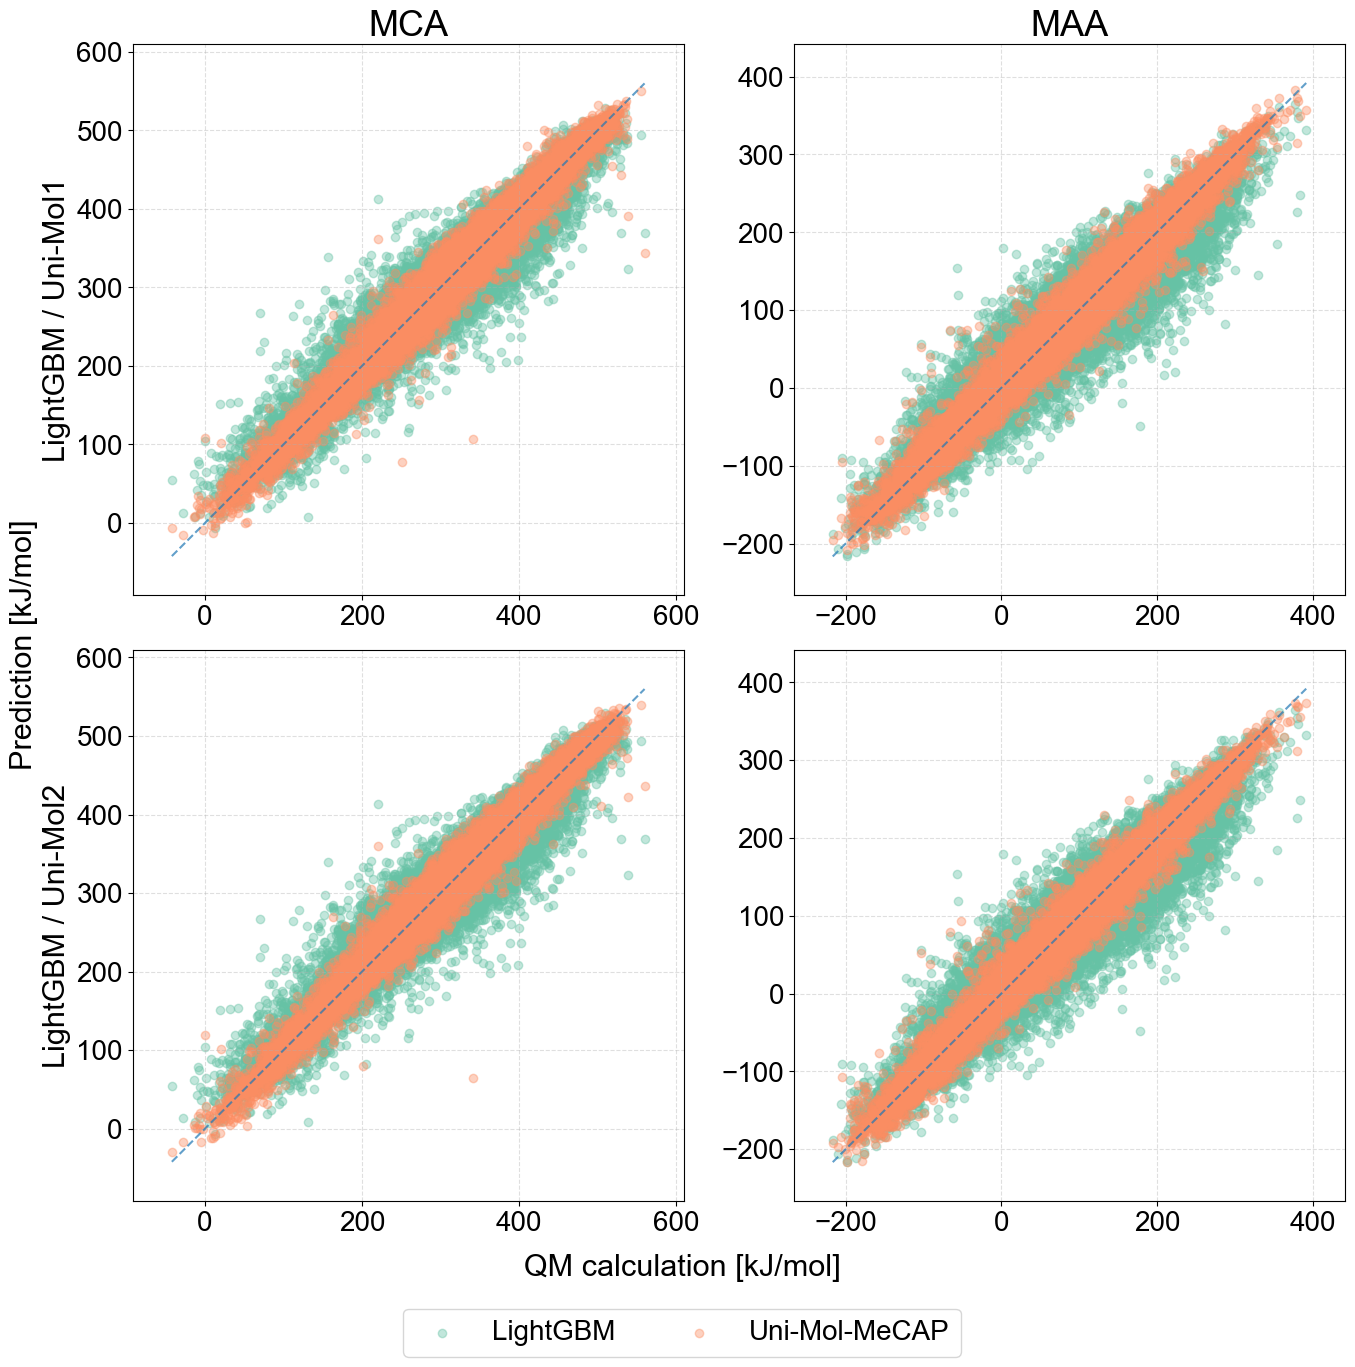

In [ ]:
import matplotlib.pyplot as plt
from mod_for_analysis import load_csv, load_pred_value, stats_and_plot

alpha = 0.4
base_font_size = 20

ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)

ESNUEL_COLOR = '#66c2a5'
UNIMOL_COLOR = '#fc8d62'

plot, axes = plt.subplots(2, 2, figsize=(14, 13))
axes = axes.flatten()

legend_handles = {}

def make_parity_plot(task_name, ax):
    pred_target = 'MCA_values' if 'mca' in task_name else 'MAA_values'
    task_target = 'nuc' if 'mca' in task_name else 'elec'
    df = load_csv(f'./results/{task_name}/predictions.csv')
    df['esnuelML'] = load_pred_value(f'./references/esnuelML_{task_target}_predicted_values.csv')
    df_test = df[df['Set']=='Test']

    esnuel_scatter = ax.scatter(df_test[pred_target], df_test['esnuelML'], alpha=alpha, color=ESNUEL_COLOR)
    if 'LightGBM' not in legend_handles:
        # esnuel_scatter.set_alpha(1.0)
        legend_handles['LightGBM'] = esnuel_scatter

    collections_before = len(ax.collections)

    stats_and_plot(
        df_test[pred_target],
        df_test['pred'],
        ax=ax,
        title=pred_target[:3],
        x_label='QM calculation [kJ/mol]',
        y_label='',
        alpha=alpha,
        visualize_stats=False,
    )

    new_collections = [coll for coll in ax.collections[collections_before:] if coll is not esnuel_scatter]
    if new_collections:
        unimol_scatter = new_collections[0]
        unimol_scatter.set_facecolor(UNIMOL_COLOR)
        unimol_scatter.set_edgecolor(UNIMOL_COLOR)
        # unimol_scatter.set_alpha(1.0)
        if 'Uni-Mol-MeCAP' not in legend_handles:
            legend_handles['Uni-Mol-MeCAP'] = unimol_scatter

    ax.tick_params(axis='both', labelsize=ticks_font_size)
    ax.title.set_size(title_font_size)

make_parity_plot('mecap_ref_mca_layer_0', axes[0])
axes[0].set_xlabel('')
axes[0].set_ylabel('LightGBM / Uni-Mol1', fontsize=label_font_size)
axes[0].set_aspect('equal')

make_parity_plot('mecap_ref_maa_layer_0', axes[1])
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_aspect('equal')

make_parity_plot('mecap_ref_mca_v2_layer_0', axes[2])
axes[2].set_title('')
axes[2].set_xlabel('')
axes[2].set_ylabel('LightGBM / Uni-Mol2', fontsize=label_font_size)
axes[2].set_aspect('equal')

make_parity_plot('mecap_ref_maa_v2_layer_0', axes[3])
axes[3].set_title('')
axes[3].set_xlabel('')
axes[3].set_ylabel('')
axes[3].set_aspect('equal')

# plot.supxlabel('QM calculation [kJ/mol]', fontsize=label_font_size, y=0.1)
plot.supxlabel('QM calculation [kJ/mol]', fontsize=label_font_size)
plot.supylabel('Prediction [kJ/mol]', fontsize=label_font_size)

plot.tight_layout()
# plot.subplots_adjust(bottom=0.15)

legend_labels = ['LightGBM', 'Uni-Mol-MeCAP']
legend_handles_list = [legend_handles[label] for label in legend_labels if label in legend_handles]
plot.legend(
    legend_handles_list,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0),
    ncol=len(legend_handles_list),
    # frameon=False,
    fontsize=int(base_font_size),
)

plot.show()

## Visualization of compounds with large-errorred predictions by Uni-Mol1-MeCAPs

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


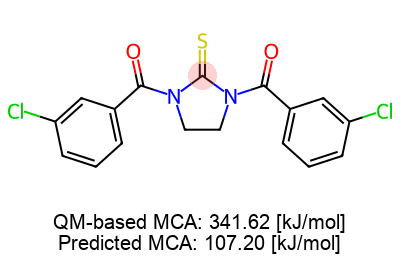

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


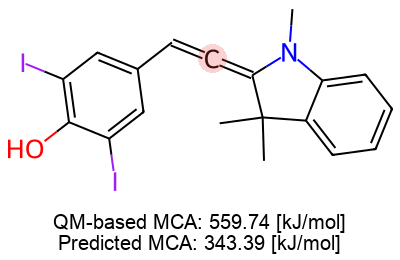

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


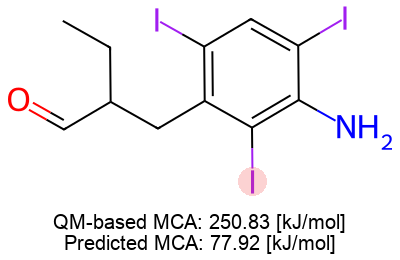

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


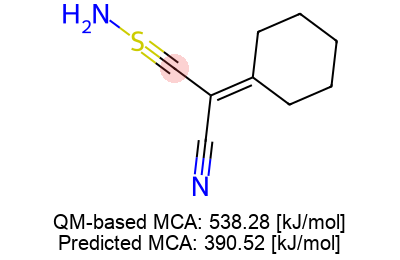

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


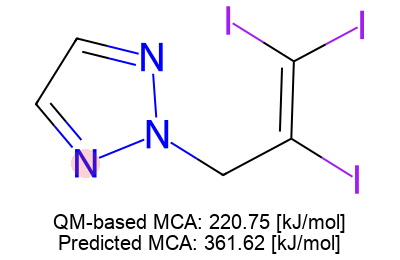

In [ ]:
from mod_for_analysis import load_csv, visualize_smiles_highlight

df = load_csv('./results/mecap_ref_mca_layer_0/predictions.csv')
df = df[df['Set']=='Test']
df['abs_error'] = (df['pred'] - df['MCA_values']).abs()
df.sort_values('abs_error',ascending=False,inplace=True)

for _, row in df[['smiles','nuc_sites','MCA_values','pred','abs_error']].head().iterrows():
    fig = visualize_smiles_highlight(row['smiles'],[row['nuc_sites']],f"{row['MCA_values']:.2f}",f"{row['pred']:.2f}",highlight_thickness_px=0,image_size=(400, 200),font_size=20)
    display(fig)


## Visualization of compounds well predicted by Uni-Mol1-MeCAPs but poorly predicted by ESNUEL_ML

===== MCA =====
Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


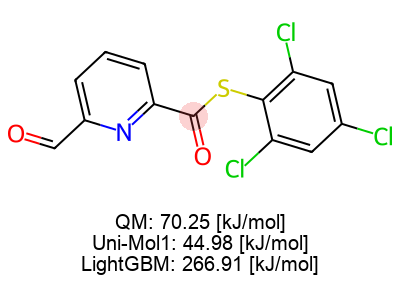

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


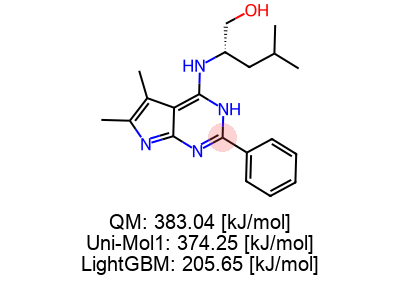

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


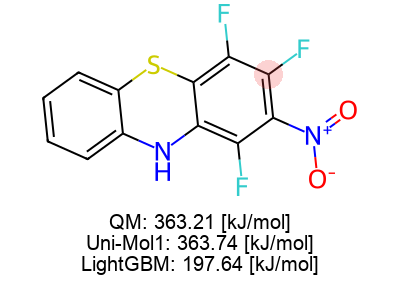

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


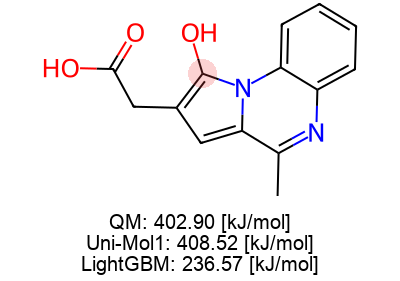

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


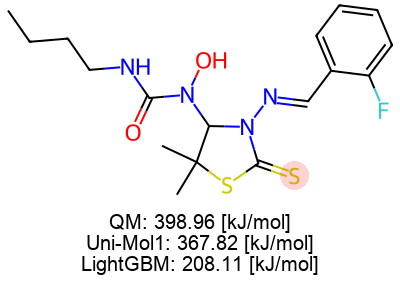



===== MAA =====
Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


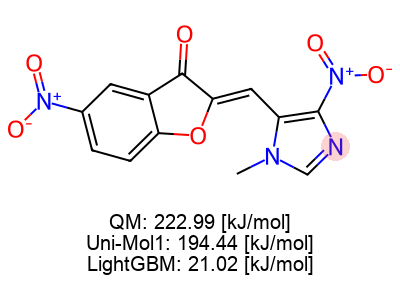

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


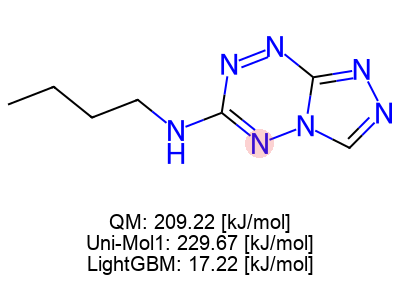

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


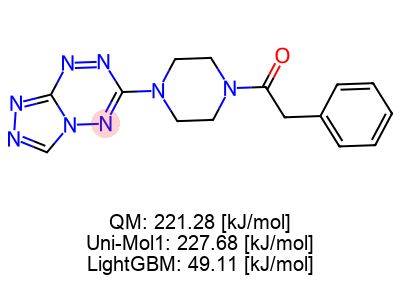

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


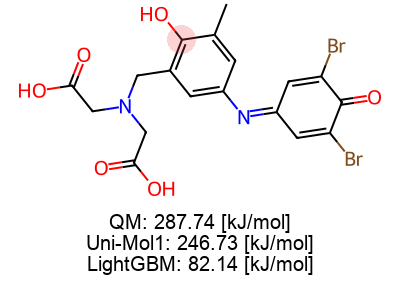

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


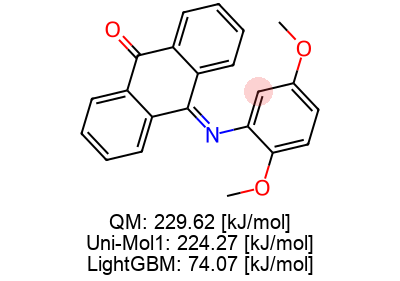

In [ ]:
from mod_for_analysis import load_csv, load_pred_value, visualize_smiles_highlight

# MCA
df = load_csv(f'./results/mecap_ref_mca_layer_0/predictions.csv')
df['esnuelML'] = load_pred_value('./references/esnuelML_nuc_predicted_values.csv')
df = df[df['Set']=='Test'].copy()
df['unimol_error'] = (df['MCA_values'] - df['pred']).abs()
df['esnuel_error'] = (df['MCA_values'] - df['esnuelML']).abs()
df['error_diff']   = df['unimol_error'] - df['esnuel_error']
df.sort_values('error_diff',inplace=True)

print("===== MCA =====")
for _, row in df[['smiles','nuc_sites','MCA_values','pred','esnuelML']].head().iterrows():
    fig = visualize_smiles_highlight(row['smiles'],[row['nuc_sites']],f"{row['MCA_values']:.2f}",f"{row['pred']:.2f}",
                                     caption_fmt="QM: {} [kJ/mol]\nUni-Mol1: {} [kJ/mol]",
                                     caption_extra={"LightGBM": f"{row['esnuelML']:.2f} [kJ/mol]"},
                                    #  highlight_color=(246, 207, 211, 100),
                                     highlight_thickness_px=0,
                                     image_size=(400, 200), font_size=20)
    display(fig)
print("\n")

# MAA
df = load_csv(f'./results/mecap_ref_maa_layer_0/predictions.csv')
df['esnuelML'] = load_pred_value('./references/esnuelML_elec_predicted_values.csv')
df = df[df['Set']=='Test'].copy()
df['unimol_error'] = (df['MAA_values'] - df['pred']).abs()
df['esnuel_error'] = (df['MAA_values'] - df['esnuelML']).abs()
df['error_diff']   = df['unimol_error'] - df['esnuel_error']
df.sort_values('error_diff',inplace=True)

print("===== MAA =====")
for _, row in df[['smiles','elec_sites','MAA_values','pred','esnuelML']].head().iterrows():
    fig = visualize_smiles_highlight(row['smiles'],[row['elec_sites']],f"{row['MAA_values']:.2f}",f"{row['pred']:.2f}",
                                     caption_fmt="QM: {} [kJ/mol]\nUni-Mol1: {} [kJ/mol]",
                                     caption_extra={"LightGBM": f"{row['esnuelML']:.2f} [kJ/mol]"},
                                    #  highlight_color=(246, 207, 211, 254),
                                     highlight_thickness_px=0,
                                     image_size=(400, 200), font_size=20)
    display(fig)



# Analysis on "rare" substructure -focusing on thiourea and allene-

In [ ]:
# Count number of "rare" substructures

import pandas as pd
from tqdm import tqdm
from rdkit import Chem
from mod_for_analysis import thu_aln_smirks_dict, element_dict, substructure_match

queries = {key: Chem.MolFromSmarts(sma) for key, sma in thu_aln_smirks_dict.items()}

df  = pd.read_csv('./references/QMdata4ML/df_nuc_x_with_name_fold.csv',index_col=0)

df_nuc_train  = df[df['Set_fold1']=='train']

count = {name: 0 for name in queries.keys()}

for smi, gdf in tqdm(df_nuc_train.groupby('smiles'),desc='Substructure Match',total=len(df_nuc_train['smiles'].unique())):
    idxs = [int(idx) for idx in gdf['nuc_sites']]
    for name, query in queries.items():
        elem = element_dict[name]
        subs = substructure_match(Chem.MolFromSmiles(smi),query)
        for sub in subs:
            if int(sub[elem]) in idxs:
                count[name] = count[name] + 1

print(count)

Substructure Match: 100%|██████████| 47792/47792 [00:25<00:00, 1847.99it/s]

{'thiourea': 8, 'allene': 65}


# Analysis on Bemis-Murcko-scaffold-based split

In [1]:
'''Statistical table for Bemis-Murcko-scaffold-based split'''
import pandas as pd
from mod_for_analysis import load_csv, calculate_stats, extract_best_epoch

mca_dict, maa_dict = {}, {}

# MCA
be_ = extract_best_epoch(f'./results/mecap_scaf_mca_layer_0/train.log')
df = load_csv(f'./results/mecap_scaf_mca_layer_0/predictions.csv')
df_test = df[df['Set_scaffold']=='test']
r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
mca_dict[f'UniMol1_MCA'] = {
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

# MAA
be_ = extract_best_epoch(f'./results/mecap_scaf_maa_layer_0/train.log')
df = load_csv(f'./results/mecap_scaf_maa_layer_0/predictions.csv')
df_test = df[df['Set_scaffold']=='test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
maa_dict[f'UniMol1_MAA'] = {
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}


print('===MCA===')
display(pd.DataFrame(mca_dict).T)

print('===MAA===')
display(pd.DataFrame(maa_dict).T)

===MCA===


,best_epoch,r,r2,rmse
UniMol1_MCA,49.0,0.987887,0.975083,11.51688


===MAA===


,best_epoch,r,r2,rmse
UniMol1_MAA,44.0,0.983143,0.966054,13.228233


<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_912094/3967191910.py:66: SyntaxWarning: invalid escape sequence '\m'
  f"n = {int(r['n'])}\n $\mu D$ = {r['mdist_mean']:.2f}",


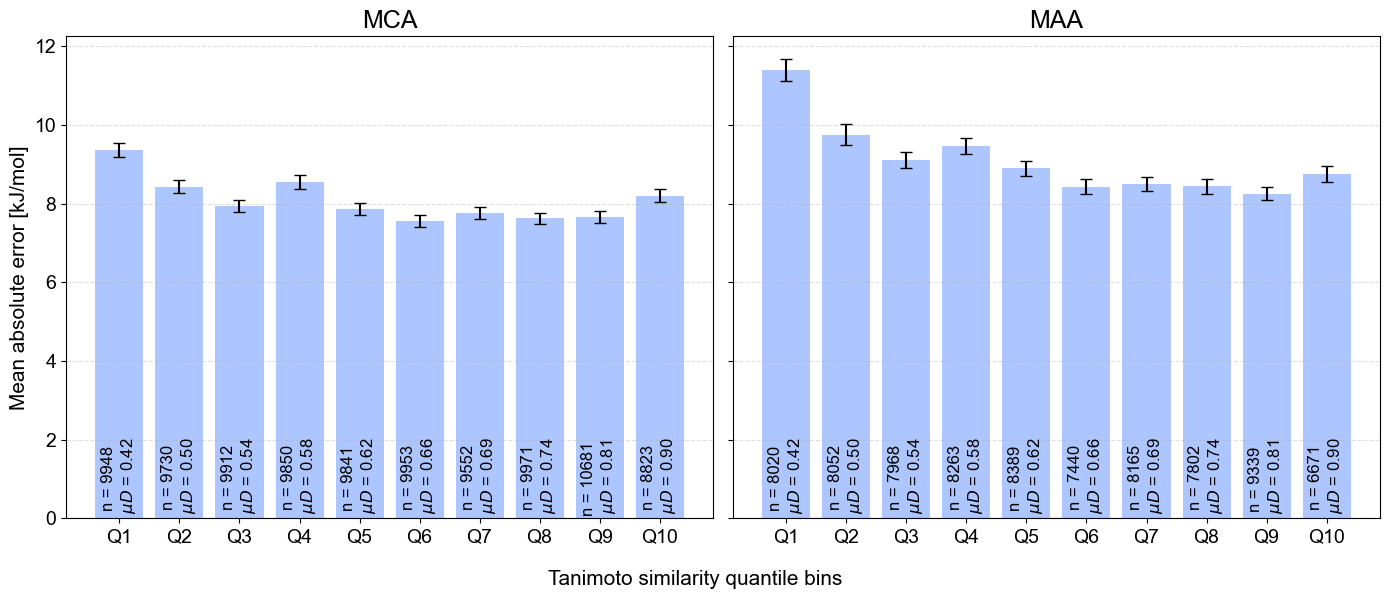

===MCA===


,mdist_bin,mdist_mean,abs_error_mean,abs_error_std,n,abs_error_se,abs_error_ci95
0,"(0.142, 0.474]",0.420911,9.361894,9.535732,9948,0.095606,0.187388
1,"(0.474, 0.519]",0.499325,8.427711,8.450717,9730,0.085672,0.167916
2,"(0.519, 0.564]",0.543919,7.937610,8.052195,9912,0.080879,0.158522
3,"(0.564, 0.604]",0.584943,8.557869,9.112231,9850,0.091814,0.179954
4,"(0.604, 0.636]",0.621479,7.861983,8.085226,9841,0.081503,0.159746
5,"(0.636, 0.676]",0.657040,7.548868,7.623021,9953,0.076410,0.149764
6,"(0.676, 0.712]",0.694764,7.753532,7.426638,9552,0.075988,0.148937
7,"(0.712, 0.769]",0.739894,7.621365,7.537528,9971,0.075485,0.147950
8,"(0.769, 0.833]",0.809170,7.658351,7.615411,10681,0.073686,0.144425
9,"(0.833, 1.0]",0.899523,8.197770,8.123889,8823,0.086488,0.169516


===MAA===


,mdist_bin,mdist_mean,abs_error_mean,abs_error_std,n,abs_error_se,abs_error_ci95
0,"(0.213, 0.474]",0.422123,11.395032,12.485057,8020,0.139413,0.273250
1,"(0.474, 0.519]",0.499396,9.753008,12.316432,8052,0.137257,0.269023
2,"(0.519, 0.562]",0.542980,9.108610,9.336616,7968,0.104596,0.205008
3,"(0.562, 0.6]",0.583297,9.464791,9.616396,8263,0.105790,0.207348
4,"(0.6, 0.636]",0.621048,8.900975,8.832411,8389,0.096433,0.189008
5,"(0.636, 0.674]",0.655860,8.430976,8.398433,7440,0.097367,0.190839
6,"(0.674, 0.711]",0.692791,8.498201,8.404934,8165,0.093016,0.182311
7,"(0.711, 0.767]",0.736757,8.436312,8.483550,7802,0.096045,0.188248
8,"(0.767, 0.833]",0.806271,8.253155,7.946653,9339,0.082231,0.161172
9,"(0.833, 1.0]",0.897679,8.761399,8.536244,6671,0.104513,0.204846


In [5]:
"""Correlation of distance and prediction error"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mod_for_analysis import load_csv

N_BINS = 10
UNIMOL_COLOR = '#5F8FFF'

base_font_size = 14

ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)


plt.rcParams["font.family"] = "Arial"


def summarize_by_mdist_quantile(df, true_col, pred_col="pred", dist_col="MDist", n_bins=N_BINS):
    d = df[[true_col, pred_col, dist_col]].dropna().copy()
    d["abs_error"] = (d[pred_col] - d[true_col]).abs()
    d["mdist_bin"] = pd.qcut(d[dist_col], q=n_bins, duplicates="drop")

    out = (
        d.groupby("mdist_bin", observed=True)
        .agg(
            mdist_mean=(dist_col, "mean"),
            abs_error_mean=("abs_error", "mean"),
            abs_error_std=("abs_error", "std"),
            n=("abs_error", "size"),
        )
        .reset_index()
        .sort_values("mdist_mean")
    )

    # 95% CI (normal approximation): mean ± 1.96 * std/sqrt(n)
    out["abs_error_se"] = out["abs_error_std"] / np.sqrt(out["n"])
    out["abs_error_ci95"] = 1.96 * out["abs_error_se"]
    return out


def plot_error_hist(ax, stats_df, title):
    x = np.arange(len(stats_df))
    labels = [f"Q{i+1}" for i in range(len(stats_df))]

    ax.bar(
        x,
        stats_df["abs_error_mean"],
        yerr=stats_df["abs_error_ci95"].fillna(0.0),
        capsize=4,
        alpha=0.5,
        color=UNIMOL_COLOR,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.tick_params(axis='both', labelsize=ticks_font_size)
    ax.set_xlabel("Mahalanobis distance quantile bins", fontsize=label_font_size)
    ax.set_ylabel("Mean absolute error [kJ/mol]", fontsize=label_font_size)
    ax.set_title(title, fontsize=title_font_size)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for i, (_, r) in enumerate(stats_df.iterrows()):
        ax.text(
            i, 0,
            f"n = {int(r['n'])}\n $\mu D$ = {r['mdist_mean']:.2f}",
            ha="center", va="bottom", fontsize=int(ticks_font_size-2), rotation=90
        )


# MCA
df = load_csv("./results/mecap_scaf_mca_layer_0/predictions.csv")
df_test_mca = df[df["Set_scaffold"] == "test"].copy()
mca_stats = summarize_by_mdist_quantile(df_test_mca, true_col="MCA_values", dist_col='ScafMaxSim')

# MAA
df = load_csv("./results/mecap_scaf_maa_layer_0/predictions.csv")
df_test_maa = df[df["Set_scaffold"] == "test"].copy()
maa_stats = summarize_by_mdist_quantile(df_test_maa, true_col="MAA_values", dist_col='ScafMaxSim')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
plot_error_hist(axes[0], mca_stats, "MCA")
plot_error_hist(axes[1], maa_stats, "MAA")

axes[0].set_xlabel('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
fig.supxlabel('Tanimoto similarity quantile bins', fontsize=label_font_size)

plt.tight_layout()
plt.show()

print("===MCA===")
display(mca_stats)

print("===MAA===")
display(maa_stats)

<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_912094/96630011.py:66: SyntaxWarning: invalid escape sequence '\m'
  f"n = {int(r['n'])}\n $\mu D$ = {r['mdist_mean']:.2f}",


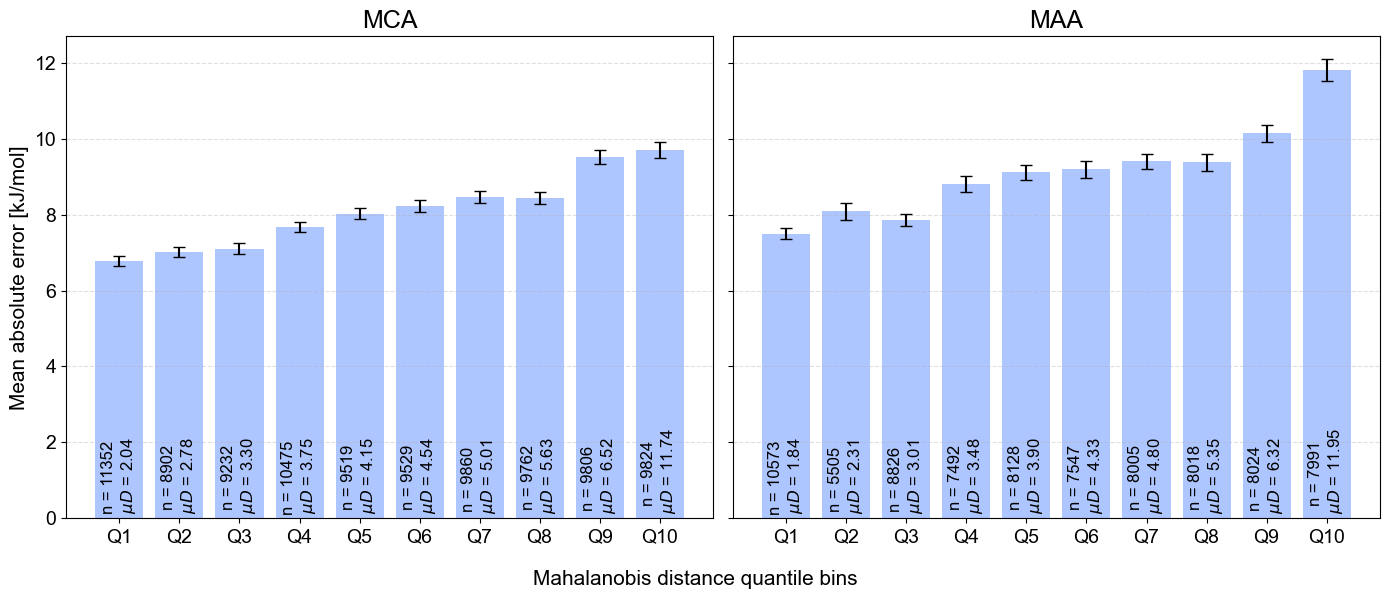

===MCA===


,mdist_bin,mdist_mean,abs_error_mean,abs_error_std,n,abs_error_se,abs_error_ci95
0,"(2.027, 2.051]",2.036206,6.770266,7.034218,11352,0.066021,0.129400
1,"(2.051, 3.065]",2.783195,7.016452,6.873144,8902,0.072847,0.142780
2,"(3.065, 3.503]",3.297052,7.106621,7.258871,9232,0.075548,0.148073
3,"(3.503, 3.937]",3.745870,7.672505,7.427850,10475,0.072575,0.142247
4,"(3.937, 4.353]",4.148896,8.027412,7.696091,9519,0.078881,0.154608
5,"(4.353, 4.762]",4.542567,8.239245,7.911751,9529,0.081049,0.158857
6,"(4.762, 5.278]",5.012103,8.458740,8.066349,9860,0.081234,0.159219
7,"(5.278, 6.007]",5.626618,8.443776,8.259057,9762,0.083591,0.163839
8,"(6.007, 7.179]",6.515446,9.519008,9.498670,9806,0.095922,0.188007
9,"(7.179, 66.524]",11.740339,9.710750,10.661218,9824,0.107563,0.210823


===MAA===


,mdist_bin,mdist_mean,abs_error_mean,abs_error_std,n,abs_error_se,abs_error_ci95
0,"(1.836, 1.85]",1.841587,7.502608,7.672403,10573,0.074616,0.146247
1,"(1.85, 2.676]",2.309723,8.088429,8.577431,5505,0.115606,0.226587
2,"(2.676, 3.18]",3.009343,7.860206,7.748269,8826,0.082475,0.161651
3,"(3.18, 3.705]",3.479577,8.806359,8.968004,7492,0.103609,0.203073
4,"(3.705, 4.1]",3.898977,9.113601,8.690475,8128,0.096394,0.188933
5,"(4.1, 4.545]",4.331933,9.194956,10.302487,7547,0.118592,0.232440
6,"(4.545, 5.052]",4.801950,9.402233,9.277910,8005,0.103698,0.203248
7,"(5.052, 5.704]",5.349688,9.379663,9.994638,8018,0.111618,0.218771
8,"(5.704, 7.18]",6.322880,10.139099,10.068113,8024,0.112396,0.220297
9,"(7.18, 101.318]",11.948312,11.804830,13.210031,7991,0.147776,0.289641


In [2]:
"""Correlation of distance and prediction error"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mod_for_analysis import load_csv

N_BINS = 10
UNIMOL_COLOR = '#5F8FFF'

base_font_size = 14

ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)


plt.rcParams["font.family"] = "Arial"


def summarize_by_mdist_quantile(df, true_col, pred_col="pred", dist_col="MDist", n_bins=N_BINS):
    d = df[[true_col, pred_col, dist_col]].dropna().copy()
    d["abs_error"] = (d[pred_col] - d[true_col]).abs()
    d["mdist_bin"] = pd.qcut(d[dist_col], q=n_bins, duplicates="drop")

    out = (
        d.groupby("mdist_bin", observed=True)
        .agg(
            mdist_mean=(dist_col, "mean"),
            abs_error_mean=("abs_error", "mean"),
            abs_error_std=("abs_error", "std"),
            n=("abs_error", "size"),
        )
        .reset_index()
        .sort_values("mdist_mean")
    )

    # 95% CI (normal approximation): mean ± 1.96 * std/sqrt(n)
    out["abs_error_se"] = out["abs_error_std"] / np.sqrt(out["n"])
    out["abs_error_ci95"] = 1.96 * out["abs_error_se"]
    return out


def plot_error_hist(ax, stats_df, title):
    x = np.arange(len(stats_df))
    labels = [f"Q{i+1}" for i in range(len(stats_df))]

    ax.bar(
        x,
        stats_df["abs_error_mean"],
        yerr=stats_df["abs_error_ci95"].fillna(0.0),
        capsize=4,
        alpha=0.5,
        color=UNIMOL_COLOR,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.tick_params(axis='both', labelsize=ticks_font_size)
    ax.set_xlabel("Mahalanobis distance quantile bins", fontsize=label_font_size)
    ax.set_ylabel("Mean absolute error [kJ/mol]", fontsize=label_font_size)
    ax.set_title(title, fontsize=title_font_size)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for i, (_, r) in enumerate(stats_df.iterrows()):
        ax.text(
            i, 0,
            f"n = {int(r['n'])}\n $\mu D$ = {r['mdist_mean']:.2f}",
            ha="center", va="bottom", fontsize=int(ticks_font_size-2), rotation=90
        )


# MCA
df = load_csv("./results/mecap_scaf_mca_layer_0/predictions.csv")
df_test_mca = df[df["Set_scaffold"] == "test"].copy()
mca_stats = summarize_by_mdist_quantile(df_test_mca, true_col="MCA_values")

# MAA
df = load_csv("./results/mecap_scaf_maa_layer_0/predictions.csv")
df_test_maa = df[df["Set_scaffold"] == "test"].copy()
maa_stats = summarize_by_mdist_quantile(df_test_maa, true_col="MAA_values")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
plot_error_hist(axes[0], mca_stats, "MCA")
plot_error_hist(axes[1], maa_stats, "MAA")

axes[0].set_xlabel('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
fig.supxlabel('Mahalanobis distance quantile bins', fontsize=label_font_size)

plt.tight_layout()
plt.show()

print("===MCA===")
display(mca_stats)

print("===MAA===")
display(maa_stats)

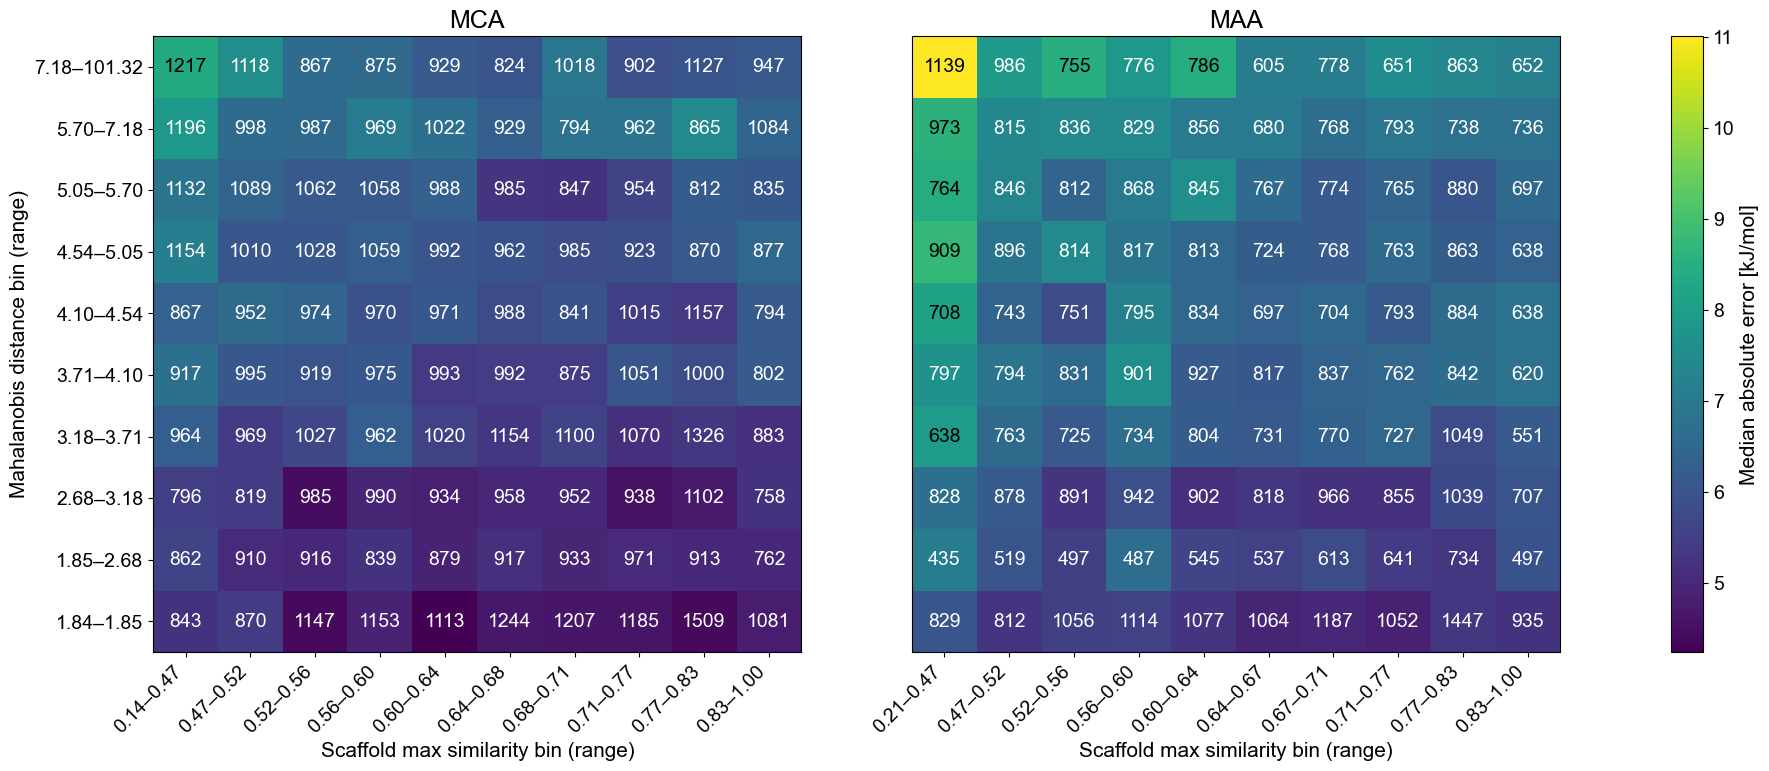

In [26]:
"""Correlation of distance and prediction error"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mod_for_analysis import load_csv

# 2D-binning setting
N_BINS_SIM = 10
N_BINS_MDIST = 10
MIN_CELL_N = 200
HEATMAP_CMAP = "viridis"
MASK_COLOR = "lightgray"

base_font_size = 14
ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)

plt.rcParams["font.family"] = "Arial"


def _trimmed_mean(x, trim=0.1):
    if len(x) == 0:
        return np.nan
    lo, hi = x.quantile(trim), x.quantile(1 - trim)
    return x[(x >= lo) & (x <= hi)].mean()


def _format_interval_labels(interval_index, fmt="{:.3f}"):
    """
    Convert pandas IntervalIndex/Categorical interval categories to readable strings.
    Example: (0.123, 0.456] -> "0.123–0.456"
    """
    labels = []
    for iv in interval_index:
        if pd.isna(iv):
            labels.append("")
            continue
        # iv is a pandas Interval
        labels.append(f"{fmt.format(iv.left)}–{fmt.format(iv.right)}")
    return labels


def summarize_2d_error(
    df,
    true_col,
    pred_col="pred",
    sim_col="ScafMaxSim",
    mdist_col="MDist",
    n_bins_sim=N_BINS_SIM,
    n_bins_mdist=N_BINS_MDIST,
    min_cell_n=MIN_CELL_N,
    use_trimmed_mean=False,
    trim=0.1,
):
    d = df[[true_col, pred_col, sim_col, mdist_col]].dropna().copy()
    d["abs_error"] = (d[pred_col] - d[true_col]).abs()

    # qcut returns categorical intervals
    d["sim_bin"] = pd.qcut(d[sim_col], q=n_bins_sim, duplicates="drop")
    d["mdist_bin"] = pd.qcut(d[mdist_col], q=n_bins_mdist, duplicates="drop")

    agg_fn = (lambda s: _trimmed_mean(s, trim=trim)) if use_trimmed_mean else "median"

    g = (
        d.groupby(["sim_bin", "mdist_bin"], observed=True)
        .agg(
            error=("abs_error", agg_fn),
            n=("abs_error", "size"),
        )
        .reset_index()
    )

    heat_error = g.pivot(index="mdist_bin", columns="sim_bin", values="error")
    heat_n = g.pivot(index="mdist_bin", columns="sim_bin", values="n").fillna(0)

    # mask sparse cells
    heat_error = heat_error.mask(heat_n < min_cell_n)
    return g, heat_error, heat_n


def plot_2d_error_heatmap(
    ax,
    heat_error,
    heat_n,
    title,
    cmap=HEATMAP_CMAP,
    vmin=None,
    vmax=None,
    tick_fmt="{:.3f}",
    cell_fontsize=None,
):
    m = np.ma.masked_invalid(heat_error.values)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(MASK_COLOR)

    im = ax.imshow(m, aspect="auto", origin="lower", cmap=cmap_obj, vmin=vmin, vmax=vmax)

    # Use interval ranges as tick labels
    x_intervals = list(heat_error.columns)
    y_intervals = list(heat_error.index)
    x_labels = _format_interval_labels(x_intervals, fmt=tick_fmt)
    y_labels = _format_interval_labels(y_intervals, fmt=tick_fmt)

    ax.set_xticks(np.arange(heat_error.shape[1]))
    ax.set_yticks(np.arange(heat_error.shape[0]))
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_yticklabels(y_labels)

    ax.tick_params(axis="both", labelsize=ticks_font_size)
    ax.set_xlabel("Scaffold max similarity bin (range)", fontsize=label_font_size)
    ax.set_ylabel("Mahalanobis distance bin (range)", fontsize=label_font_size)
    ax.set_title(title, fontsize=title_font_size)

    # Cell count annotation (no 'n='), bigger font, color adapted to background
    if cell_fontsize is None:
        cell_fontsize = ticks_font_size  # bigger than before

    # For text color decision, normalize by vmin/vmax if available
    if vmin is None or vmax is None or not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        # Fallback: always white text
        def _text_color(_val):
            return "white"
    else:
        def _text_color(val):
            # Use white on darker colors, black on brighter colors
            # Threshold at mid-point in normalized space
            t = (val - vmin) / (vmax - vmin)
            return "white" if t < 0.55 else "black"

    for i in range(heat_n.shape[0]):
        for j in range(heat_n.shape[1]):
            n_ij = int(heat_n.iloc[i, j]) if not np.isnan(heat_n.iloc[i, j]) else 0
            val = heat_error.iloc[i, j]
            if np.isnan(val):
                # Masked cell: use dark text on gray background
                color = "black"
            else:
                color = _text_color(float(val))
            ax.text(j, i, f"{n_ij}", ha="center", va="center", fontsize=cell_fontsize, color=color)

    return im


# ---- Load and summarize ----
# MCA
df = load_csv("./results/mecap_scaf_mca_layer_0/predictions.csv")
df_test_mca = df[df["Set_scaffold"] == "test"].copy()
mca_g, mca_heat_error, mca_heat_n = summarize_2d_error(df_test_mca, true_col="MCA_values")

# MAA
df = load_csv("./results/mecap_scaf_maa_layer_0/predictions.csv")
df_test_maa = df[df["Set_scaffold"] == "test"].copy()
maa_g, maa_heat_error, maa_heat_n = summarize_2d_error(df_test_maa, true_col="MAA_values")

# Shared color range (robust option: use percentiles if outliers dominate)
vals = np.concatenate([mca_heat_error.to_numpy().ravel(), maa_heat_error.to_numpy().ravel()])
vals = vals[np.isfinite(vals)]
shared_vmin, shared_vmax = float(vals.min()), float(vals.max())
# If you want robust scaling, uncomment:
# shared_vmin, shared_vmax = np.quantile(vals, [0.02, 0.98])

# ---- Plot with dedicated colorbar axis (no overlap) ----
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.25)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
cax = fig.add_subplot(gs[0, 2])

im0 = plot_2d_error_heatmap(
    ax0, mca_heat_error, mca_heat_n, "MCA",
    vmin=shared_vmin, vmax=shared_vmax,
    tick_fmt="{:.2f}",
    cell_fontsize=ticks_font_size,  # bigger text in cells
)
im1 = plot_2d_error_heatmap(
    ax1, maa_heat_error, maa_heat_n, "MAA",
    vmin=shared_vmin, vmax=shared_vmax,
    tick_fmt="{:.2f}",
    cell_fontsize=ticks_font_size,
)

# Hide duplicated y-label on right plot (optional)
ax1.set_ylabel("")
ax1.tick_params(axis="y", left=False, labelleft=False)

# Colorbar in separate axis
cbar = fig.colorbar(im1, cax=cax)
cbar.set_label("Median absolute error [kJ/mol]", fontsize=label_font_size)
cbar.ax.tick_params(labelsize=ticks_font_size)

plt.show()

MCA groups with non-unique ScafMaxSim: 0
MAA groups with non-unique ScafMaxSim: 0


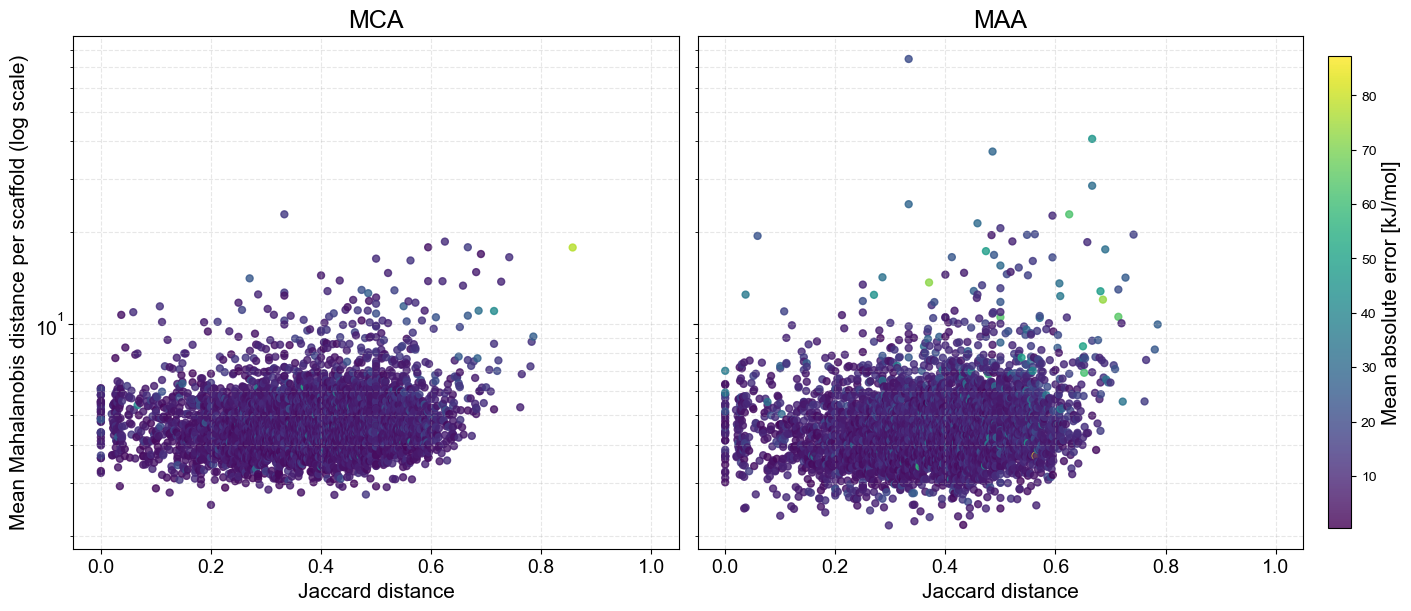

,scaffold,ScafMaxSim,ScafMaxSim_nunique,MDist_mean,abs_error_mean,n,JaccardDist
2649,O=S(=O)(c1cnn(S(=O)(=O)c2ccccc2)c1)N1CCCCCC1,1.0,1,6.139844,6.086539,11,0.0
659,O=C(CNS(=O)(=O)c1ccccc1)N1CCCCC1,1.0,1,4.768390,11.378512,13,0.0
1229,O=C(NCc1ccccc1)c1cccc(S(=O)(=O)N2CCCCCC2)c1,1.0,1,5.133761,9.762454,15,0.0
4138,c1ccc(Nc2ccnc(Nc3ccc4[nH]cnc4c3)n2)cc1,1.0,1,4.750840,6.904834,21,0.0
763,O=C(COc1ccccc1)Nc1nnc(S(=O)(=O)N2CCCCC2)s1,1.0,1,5.238452,8.853964,16,0.0


,scaffold,ScafMaxSim,ScafMaxSim_nunique,MDist_mean,abs_error_mean,n,JaccardDist
4349,c1ccc2c(c1)CC(N1CCCCC1)C2,1.0,1,3.436949,3.303182,6,0.0
1007,O=C(NC1CCCCCC1)c1ccccc1,1.0,1,5.857130,5.501439,12,0.0
228,C1CCCCCC1,1.0,1,4.886181,9.753832,4,0.0
631,O=C(CNS(=O)(=O)c1ccccc1)N1CCCCC1,1.0,1,4.433604,9.668229,8,0.0
425,O=C(CC1C(=O)NCCN1Cc1ccccc1)NC1CCCCCCC1,1.0,1,3.771467,11.431109,8,0.0


In [15]:
"""Scaffold-level scatter plot: Jaccard distance vs mean MDist, colored by prediction error"""
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from mod_for_analysis import load_csv

base_font_size = 14
ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)

plt.rcParams["font.family"] = "Arial"


def summarize_by_scaffold(
    df, true_col, pred_col="pred", sim_col="ScafMaxSim", mdist_col="MDist", scaffold_col="scaffold"
):
    d = df[[scaffold_col, sim_col, mdist_col, true_col, pred_col]].dropna().copy()
    d["abs_error"] = (d[pred_col] - d[true_col]).abs()

    out = (
        d.groupby(scaffold_col, as_index=False)
        .agg(
            ScafMaxSim=(sim_col, "first"),
            ScafMaxSim_nunique=(sim_col, "nunique"),
            MDist_mean=(mdist_col, "mean"),
            abs_error_mean=("abs_error", "mean"),
            n=("abs_error", "size"),
        )
    )
    out["JaccardDist"] = 1.0 - out["ScafMaxSim"]
    return out.sort_values("JaccardDist")


def plot_scaffold_scatter(ax, stats_df, title, norm):
    sc = ax.scatter(
        stats_df["JaccardDist"],
        stats_df["MDist_mean"],
        c=stats_df["abs_error_mean"],
        cmap="viridis",
        norm=norm,
        s=25,
        alpha=0.8,
    )
    ax.set_title(title, fontsize=title_font_size)
    ax.set_xlabel("Jaccard distance", fontsize=label_font_size)
    ax.set_ylabel("Mean Mahalanobis distance per scaffold (log scale)", fontsize=label_font_size)
    ax.set_yscale("log")
    ax.tick_params(axis="both", labelsize=ticks_font_size)
    ax.grid(True, linestyle="--", alpha=0.3, which="both")
    ax.set_xlim(-0.05, 1.05)
    return sc

smi_to_scaf = load_csv("./references/split_sim.csv")['scaffold'].to_dict()

df = load_csv("./results/mecap_scaf_mca_layer_0/predictions.csv")
df_test_mca = df[df["Set_scaffold"] == "test"].copy()
df_test_mca['scaffold'] = df_test_mca['smiles'].map(smi_to_scaf)

df = load_csv("./results/mecap_scaf_maa_layer_0/predictions.csv")
df_test_maa = df[df["Set_scaffold"] == "test"].copy()
df_test_maa['scaffold'] = df_test_maa['smiles'].map(smi_to_scaf)

# Scaffold-level summaries
mca_scaf_stats = summarize_by_scaffold(df_test_mca, true_col="MCA_values")
maa_scaf_stats = summarize_by_scaffold(df_test_maa, true_col="MAA_values")

# Optional consistency check
mca_inconsistent = (mca_scaf_stats["ScafMaxSim_nunique"] > 1).sum()
maa_inconsistent = (maa_scaf_stats["ScafMaxSim_nunique"] > 1).sum()
print(f"MCA groups with non-unique ScafMaxSim: {mca_inconsistent}")
print(f"MAA groups with non-unique ScafMaxSim: {maa_inconsistent}")

# Shared color scale across both axes
vmin = min(mca_scaf_stats["abs_error_mean"].min(), maa_scaf_stats["abs_error_mean"].min())
vmax = max(mca_scaf_stats["abs_error_mean"].max(), maa_scaf_stats["abs_error_mean"].max())
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, constrained_layout=True)
sc1 = plot_scaffold_scatter(axes[0], mca_scaf_stats, "MCA", norm)
sc2 = plot_scaffold_scatter(axes[1], maa_scaf_stats, "MAA", norm)
axes[1].set_ylabel("")

# One unified colorbar for both subplots
cbar = fig.colorbar(
    sc1,
    ax=axes,
    location="right",
    shrink=0.92,
    pad=0.02,
)
cbar.set_label("Mean absolute error [kJ/mol]", fontsize=label_font_size)

# plt.tight_layout()
plt.show()

display(mca_scaf_stats.head())
display(maa_scaf_stats.head())


In [4]:
smi_to_scaf = load_csv("./references/split_sim.csv")['scaffold'].to_dict()

df_test_maa_copy = df_test_maa.copy()
df_test_maa_copy['scaffold'] = df_test_maa_copy['smiles'].map(smi_to_scaf)
df_test_maa_copy

,smiles,elec_sites,elec_names,MAA_values,elec_GCS_3_cm5,Set,elec_SMI2GCS_3_cm5,elec_SMI2GCS_5_cm5,elec_RDKitCountFP_512,elec_RDKitGasteigerGCS_5,...,Set_fold2,Set_fold3,Set_fold4,Set_fold5,Set_scaffold,ScafMaxSim,rdkitAtomWiseFP,MDist,pred,scaffold
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
5075,CCCC(=O)Nc1cccc(NC(=O)c2ccc(F)cc2)c1,3,Amide,105.571759,"[0.56881, -0.62706, -0.67984, -0.19525, 0.0, 0...",Train_fold3,"[0.56238, -0.58382, -0.67093, -0.1865, 0.0, 0....","[0.56238, -0.58382, -0.67093, -0.1865, 0.0, 0....","[1, 4, 2, 0, 6, 3, 6, 0, 3, 5, 9, 3, 0, 3, 11,...","[0.2238592608048026, -0.27475763210685517, -0....",...,train,val,train,train,test,0.833333,"(6, 0, 0, 3, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, ...",4.695507,113.763016,O=C(Nc1ccccc1)c1ccccc1
5076,CCCC(=O)Nc1cccc(NC(=O)c2ccc(F)cc2)c1,12,Amide,135.149994,"[0.57086, -0.62624, -0.66961, -0.05199, 0.0, 0...",Train_fold5,"[0.5669, -0.58336, -0.66205, -0.04764, 0.0, 0....","[0.5669, -0.58336, -0.66205, -0.04764, 0.0, 0....","[1, 8, 1, 0, 0, 2, 3, 4, 2, 4, 14, 1, 4, 4, 1,...","[0.25516228348375275, -0.2689299055180334, -0....",...,train,train,train,val,test,0.833333,"(6, 0, 0, 3, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, ...",4.704685,131.035460,O=C(Nc1ccccc1)c1ccccc1
5077,CCCC(=O)Nc1cccc(NC(=O)c2ccc(F)cc2)c1,4,double_bond,-91.317752,"[-0.62706, 0.56881, 0.0, 0.0, 0.0, -0.67984, -...",Train_fold3,"[-0.58382, 0.56238, 0.0, 0.0, 0.0, -0.67093, -...","[-0.58382, 0.56238, 0.0, 0.0, 0.0, -0.67093, -...","[0, 2, 2, 0, 0, 0, 2, 0, 0, 2, 2, 0, 0, 2, 9, ...","[-0.27475763210685517, 0.2238592608048026, 0.0...",...,train,val,train,train,test,0.833333,"(8, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",4.099787,-93.559290,O=C(Nc1ccccc1)c1ccccc1
5078,CCCC(=O)Nc1cccc(NC(=O)c2ccc(F)cc2)c1,6,double_bond,83.405395,"[0.20759, -0.67984, -0.15423, -0.11501, 0.0, 0...",Train_fold1,"[0.20786, -0.67093, -0.13645, -0.13191, 0.0, 0...","[0.20786, -0.67093, -0.13645, -0.13191, 0.0, 0...","[1, 7, 6, 3, 0, 4, 5, 3, 0, 4, 19, 6, 0, 0, 8,...","[0.04273224362415951, -0.32602040389734804, -0...",...,train,train,train,train,test,0.833333,"(6, 1, 1, 3, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, ...",2.757468,87.908035,O=C(Nc1ccccc1)c1ccccc1
5079,CCCC(=O)Nc1cccc(NC(=O)c2ccc(F)cc2)c1,7,double_bond,72.666753,"[-0.11501, 0.20759, -0.07857, 0.12349, 0.0, -0...",Train_fold1,"[-0.13191, 0.20786, -0.07331, 0.0889, 0.0, -0....","[-0.13191, 0.20786, -0.07331, 0.0889, 0.0, -0....","[1, 2, 7, 3, 0, 4, 3, 3, 0, 3, 13, 6, 0, 0, 6,...","[-0.038382548116474034, 0.04273224362415951, -...",...,train,train,train,train,test,0.833333,"(6, 1, 1, 3, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.993032,79.921460,O=C(Nc1ccccc1)c1ccccc1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534114,CN(C)P1(N(C)C)=NC(C(F)(F)F)=NC(C(F)(F)F)=N1,7,double_bond,96.716782,"[-0.49284, 0.50647, 0.49561, 0.0, 0.0, -0.4742...",Train_fold2,"[-0.48099, 0.52735, 0.48598, 0.0, 0.0, -0.4714...","[-0.48099, 0.52735, 0.48598, 0.0, 0.0, -0.4714...","[19, 29, 42, 7, 0, 0, 2, 1, 8, 2, 8, 12, 0, 12...","[-0.19201745014467986, 0.21863644570545976, 0....",...,val,train,train,train,test,0.333333,"(7, 0, 1, 2, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, ...",32.231891,136.033690,C1=NC=NP=N1
534115,CN(C)P1(N(C)C)=NC(C(F)(F)F)=NC(C(F)(F)F)=N1,8,double_bond,260.077289,"[0.49561, -0.49284, -0.59083, 0.70517, 0.0, 0....",Train_fold1,"[0.48598, -0.48099, -0.56835, 0.68774, 0.0, 0....","[0.48598, -0.48099, -0.56835, 0.68774, 0.0, 0....","[19, 29, 2, 7, 0, 0, 2, 2, 8, 2, 4, 0, 0, 12, ...","[0.23883137097912507, -0.19201745014467986, -0...",...,train,train,train,train,test,0.333333,"(6, 0, 1, 3, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, ...",39.513705,268.508060,C1=NC=NP=N1
534116,CN(C)P1(N(C)C)=NC(C(F)(F)F)=NC(C(F)(F)F)=N1,13,double_bond,44.020932,"[-0.59083, 0.49561, 0.49529, 0.0, 0.0, -0.4928...",Train_fold3,"[-0.56835, 0.48598, 0.48598, 0.0, 0.0, -0.4809...","[-0.56835, 0.48598, 0.48598, 0.0, 0.0, -0.4809...","[15, 1, 2, 4, 0, 0, 2, 2, 8, 2, 5, 0, 2, 0, 0,...","[-0.20015349050301906, 0.238

# Conformer RMSD check (QM calculation input, RMSD-max input)

<>:37: SyntaxWarning: invalid escape sequence '\A'
<>:37: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_3521397/1193567067.py:37: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel("RMSD [$\AA$]")


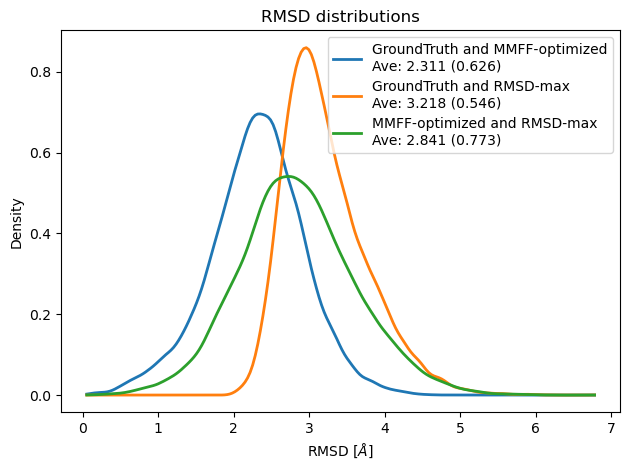

In [ ]:
import collections, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

convert_dir_name_to_met = {
    'confs_orca': 'GroundTruth',
    'confs_from_smiles_rdkit': 'MMFF-optimized',
    'rmsd_max': 'RMSD-max',
    }

df = pd.read_csv('./results/optimizing/conformation_rmsd.csv',index_col=None)
df['combi'] = df.apply(lambda row: convert_dir_name_to_met[os.path.basename(row['dir1'])] + ' and ' + convert_dir_name_to_met[os.path.basename(row['dir2'])], axis=1)

fig, ax1 = plt.subplots()

x_min, x_max = df['rmsd'].min(), df['rmsd'].max()
x_grid = np.linspace(x_min, x_max, 200)

for name, gdf in df.groupby('combi'):
    values = gdf['rmsd'].dropna()

    counter = collections.Counter(values)
    # for v, cnt in sorted(counter.items()):
    #     print(f"{v}: {cnt}")


    # ax.hist(values_arr, bins="auto", density=True, alpha=0.6, edgecolor="black")

    kde = gaussian_kde(values)

    y_kde_gth_mmff = kde(x_grid)
    
    ax1.plot(x_grid, y_kde_gth_mmff, linewidth=2, label=f'{name}\nAve: {values.mean():.3f} ({values.std():.3f})')

ax1.set_xlabel("RMSD [$\AA$]")
ax1.set_ylabel("Density")
ax1.set_title("RMSD distributions")
ax1.legend()

plt.tight_layout()
plt.show()


# Predict (xTB-optimized) - Predict (RMSD-max) plot

In [ ]:
'''Statistical table for different conformations'''
import pandas as pd
from mod_for_analysis import load_csv, calculate_stats, extract_best_epoch

mca_dict, maa_dict = {}, {}

## Ground truth
# MCA
be_ = extract_best_epoch(f'./results/different_conformation/mecap_ref_mca_gth_layer_0/train.log')
df = load_csv(f'./results/different_conformation/mecap_ref_mca_gth_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
mca_dict[f'UniMol1_MCA_GroundTruth'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

# MAA
be_ = extract_best_epoch(f'./results/different_conformation/mecap_ref_maa_gth_layer_0/train.log')
df = load_csv(f'./results/different_conformation/mecap_ref_maa_gth_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
maa_dict[f'UniMol1_MAA_GroundTruth'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

## Optimized by xTB (Uni-Mol type conformer generation)
# MCA
be_ = extract_best_epoch(f'./results/different_conformation/mecap_ref_mca_mmff_layer_0/train.log')
df = load_csv(f'./results/different_conformation/mecap_ref_mca_mmff_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
mca_dict[f'UniMol1_MCA_mmff'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

# MAA
be_ = extract_best_epoch(f'./results/different_conformation/mecap_ref_maa_mmff_layer_0/train.log')
df = load_csv(f'./results/different_conformation/mecap_ref_maa_mmff_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
maa_dict[f'UniMol1_MAA_mmff'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

## ""Far"" conformation from xTB-optimized conf
# MCA
be_ = extract_best_epoch(f'./results/different_conformation/mecap_ref_mca_rmsd_layer_0/train.log')
df = load_csv(f'./results/different_conformation/mecap_ref_mca_rmsd_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
mca_dict[f'UniMol1_MCA_rmsd'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

# MAA
be_ = extract_best_epoch(f'./results/different_conformation/mecap_ref_maa_rmsd_layer_0/train.log')
df = load_csv(f'./results/different_conformation/mecap_ref_maa_rmsd_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
maa_dict[f'UniMol1_MAA_rmsd'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

## ""Far"" conformation from xTB-optimized conf (input to xTB-optimized model)
# MAA
df = load_csv(f'./results/different_conformation/mecap_ref_maa_gth_predict_by_rmsd_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
maa_dict[f'UniMol1_MAA_xTB_from_rmsd'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': None,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}


print('===MCA===')
display(pd.DataFrame(mca_dict).T)

print('===MAA===')
display(pd.DataFrame(maa_dict).T)

===MCA===


,train,valid,test,best_epoch,r2,r,rmse
UniMol1_MCA_GroundTruth,212689.0,53360.0,46995.0,48.0,0.979244,0.989821,10.581071
UniMol1_MCA_mmff,212689.0,53360.0,46995.0,50.0,0.977607,0.989424,10.990522
UniMol1_MCA_rmsd,212689.0,53360.0,46995.0,50.0,0.977027,0.989029,11.131946


===MAA===


,train,valid,test,best_epoch,r2,r,rmse
UniMol1_MAA_GroundTruth,173350.0,43367.0,38428.0,50.0,0.971020,0.986047,11.957508
UniMol1_MAA_mmff,173350.0,43367.0,38428.0,44.0,0.970947,0.985757,11.972710
UniMol1_MAA_rmsd,173350.0,43367.0,38428.0,50.0,0.969725,0.985395,12.221881
UniMol1_MAA_xTB_from_rmsd,173350.0,43367.0,38428.0,NaN,0.945514,0.972471,16.395943


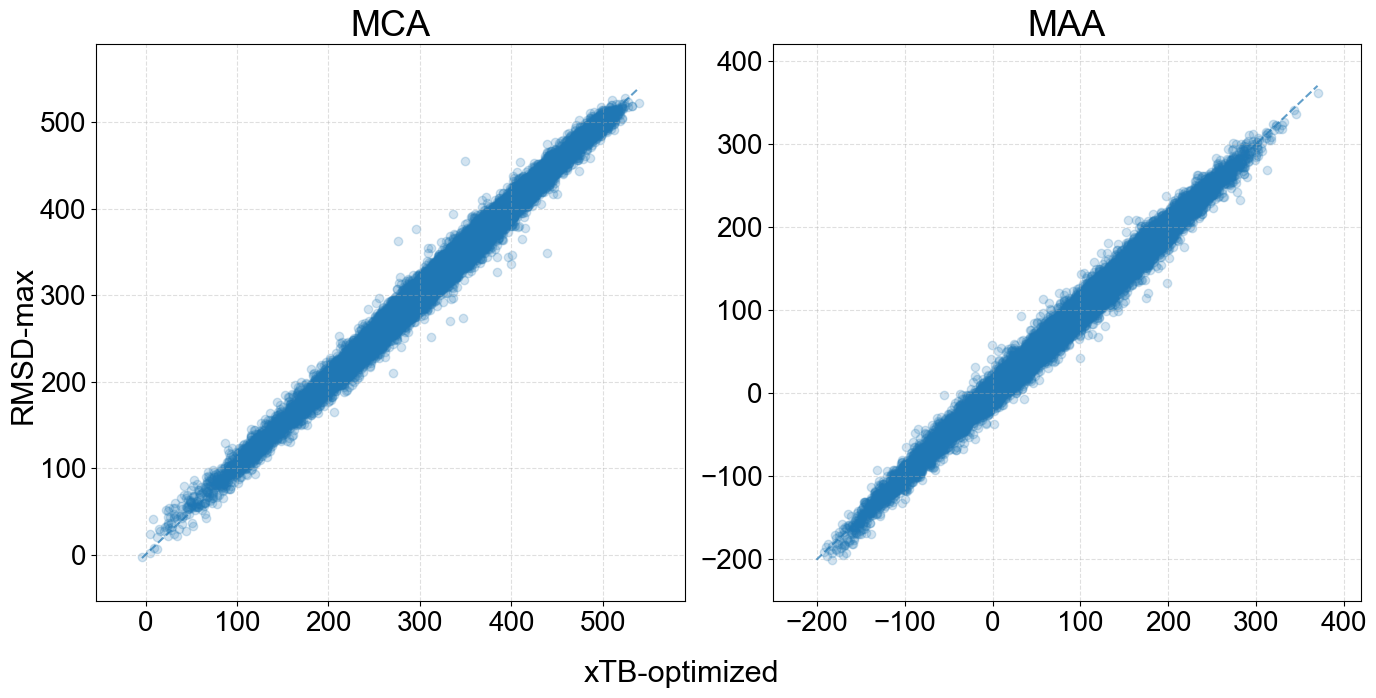

In [ ]:
import matplotlib.pyplot as plt
from mod_for_analysis import load_csv, stats_and_plot

alpha = 0.2
base_font_size = 20

ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)

# Basic plot setting
plot, axes = plt.subplots(1, 2, figsize=(14,7))
axes = axes.flatten()

def make_parity_plot(task_1, task_2, ax):
    df = load_csv(f'./results/different_conformation/{task_1}/predictions.csv')
    pred_task1 = df[df['Set']=='Test']['pred']
    df = load_csv(f'./results/different_conformation/{task_2}/predictions.csv')
    pred_task2 = df[df['Set']=='Test']['pred']
    stats_and_plot(pred_task1,pred_task2,
                ax=ax,
                title='MCA' if 'mca' in task_1.lower() else 'MAA',
                x_label='',
                y_label='',
                alpha=alpha,
                visualize_stats=False)
    # enlarge axis-label font size for axes[0]
    ax.tick_params(axis='both', labelsize=ticks_font_size)  # larger tick labels
    ax.title.set_size(title_font_size)

## Uni-Mol1
# MCA
make_parity_plot('mecap_ref_mca_gth_layer_0', 'mecap_ref_mca_rmsd_layer_0', axes[0])
axes[0].set_xlabel(''); axes[0].set_ylabel('')

# MAA
make_parity_plot('mecap_ref_maa_gth_layer_0', 'mecap_ref_maa_rmsd_layer_0', axes[1])
axes[1].set_xlabel(''); axes[1].set_ylabel('')

plot.supxlabel('xTB-optimized',fontsize=label_font_size)
plot.supylabel('RMSD-max',fontsize=label_font_size)

plot.tight_layout()

plot.show()

plot.tight_layout()

plot.show()

===MCA===
Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


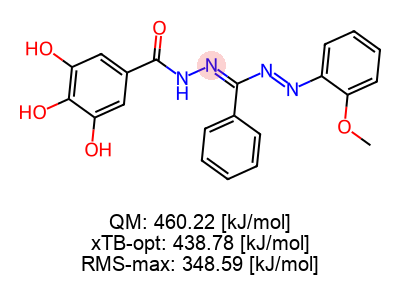

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


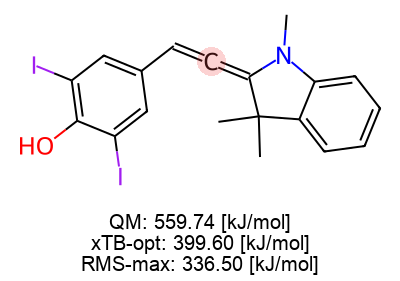

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


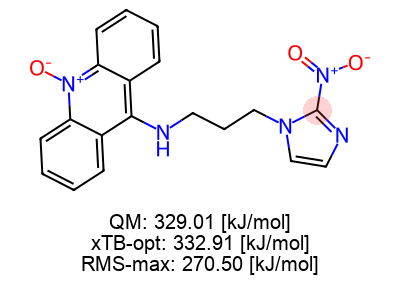

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


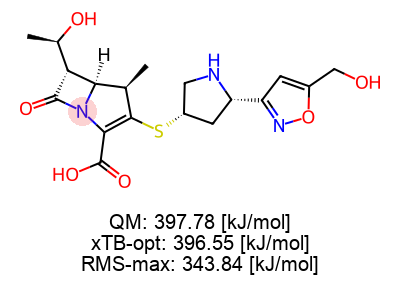

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


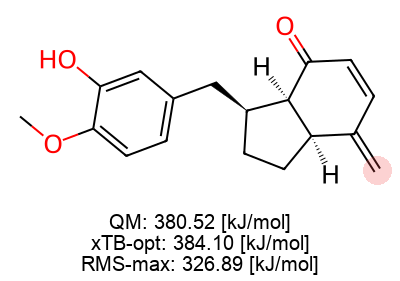

===MAA===
Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


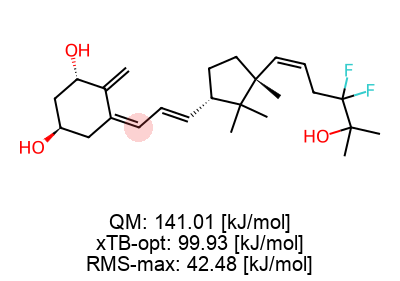

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


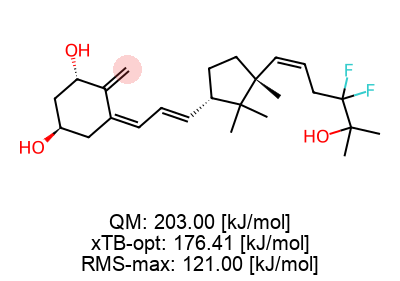

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


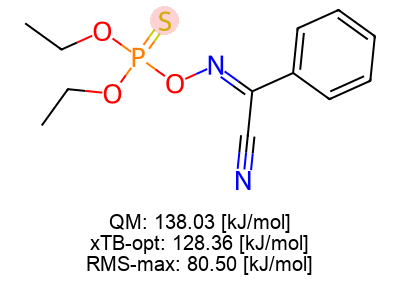

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


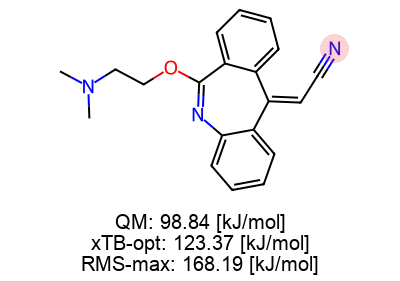

Load /usr/share/fonts/truetype/msttcorefonts/Arial.ttf


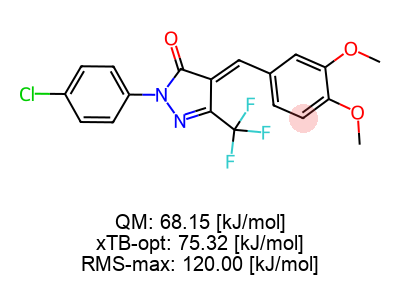

In [ ]:
from mod_for_analysis import load_csv, load_pred_value, visualize_smiles_highlight

# MCA
mca_df_task1 = load_csv(f'./results/different_conformation/mecap_ref_mca_gth_layer_0/predictions.csv')
mca_df_task1 = mca_df_task1[mca_df_task1['Set']=='Test'].copy()
mca_df_task2 = load_csv(f'./results/different_conformation/mecap_ref_mca_rmsd_layer_0/predictions.csv')
mca_df_task2 = mca_df_task2[mca_df_task2['Set']=='Test'].copy()

abs_err  = ((mca_df_task1['MCA_values'] - mca_df_task1['pred']).abs() - (mca_df_task2['MCA_values'] - mca_df_task2['pred']).abs()).sort_values()
mca_abs_err_top = abs_err.head(5).index

print('===MCA===')
for idx in mca_abs_err_top:
    fig = visualize_smiles_highlight(mca_df_task1.loc[idx,'smiles'],[mca_df_task1.loc[idx,'nuc_sites']],f"{mca_df_task1.loc[idx,'MCA_values']:.2f}",f"{mca_df_task1.loc[idx,'pred']:.2f}",
                                     caption_fmt="QM: {} [kJ/mol]\nxTB-opt: {} [kJ/mol]",
                                     caption_extra={"RMS-max": f"{mca_df_task2.loc[idx,'pred']:.2f} [kJ/mol]"},
                                    #  highlight_color=(234, 145, 152, 100),
                                     highlight_thickness_px=0,
                                     rdkit_padding=0.05,
                                     image_size=(400, 200), font_size=20)

    display(fig)

# MAA
maa_df_task1 = load_csv(f'./results/different_conformation/mecap_ref_maa_gth_layer_0/predictions.csv')
maa_df_task1 = maa_df_task1[maa_df_task1['Set']=='Test'].copy()
maa_df_task2 = load_csv(f'./results/different_conformation/mecap_ref_maa_rmsd_layer_0/predictions.csv')
maa_df_task2 = maa_df_task2[maa_df_task2['Set']=='Test'].copy()

abs_err  = ((maa_df_task1['MAA_values'] - maa_df_task1['pred']).abs() - (maa_df_task2['MAA_values'] - maa_df_task2['pred']).abs()).sort_values()
maa_abs_err_top = abs_err.head(5).index

print('===MAA===')
for idx in maa_abs_err_top:
    fig = visualize_smiles_highlight(maa_df_task1.loc[idx,'smiles'],[maa_df_task1.loc[idx,'elec_sites']],f"{maa_df_task1.loc[idx,'MAA_values']:.2f}",f"{maa_df_task1.loc[idx,'pred']:.2f}",
                                     caption_fmt="QM: {} [kJ/mol]\nxTB-opt: {} [kJ/mol]",
                                     caption_extra={"RMS-max": f"{maa_df_task2.loc[idx,'pred']:.2f} [kJ/mol]"},
                                    #  highlight_color=(234, 145, 152, 100),
                                     highlight_thickness_px=0,
                                     rdkit_padding=0.05,
                                     image_size=(400, 200), font_size=20)

    display(fig)

In [5]:
from rdkit import Chem
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import AllChem

for idx in maa_abs_err_top:
    suppl1 = Chem.SDMolSupplier(f"./references/confs_orca/{maa_df_task1.loc[idx,'name']}.sdf", removeHs=False)
    suppl2 = Chem.SDMolSupplier(f"./results/rmsd_max/{maa_df_task1.loc[idx,'name']}.sdf", removeHs=False)

    mol1 = [m for m in suppl1 if m is not None][0]
    mol2 = [m for m in suppl2 if m is not None][0]

    rdDetermineBonds.DetermineBonds(mol1)
    AllChem.AlignMol(mol1, mol2)

    mol1.SetProp('_Name','xTB_optimized')
    mol1.SetIntProp('elec_sites',int(maa_df_task1.loc[idx,'elec_sites']))
    mol2.SetProp('_Name','RMSD_max')
    mol2.SetIntProp('elec_sites',int(maa_df_task2.loc[idx,'elec_sites']))

    writer = Chem.SDWriter(f"./results/optimizing/{maa_df_task1.loc[idx,'name']}_xtb_rms.sdf")
    writer.write(mol1)
    writer.write(mol2)
    writer.close()

    print(f"Saved SDF to ./results/optimizing/{maa_df_task1.loc[idx,'name']}_xtb_rms.sdf")


Saved SDF to ./results/optimizing/eab42d3200cbf70c5e289b1c707410f8_xtb_rms.sdf
Saved SDF to ./results/optimizing/eab42d3200cbf70c5e289b1c707410f8_xtb_rms.sdf
Saved SDF to ./results/optimizing/8e6ee39ca19e318e86a748be191e7840_xtb_rms.sdf
Saved SDF to ./results/optimizing/17099f444306b017869f57f27f02ad4a_xtb_rms.sdf
Saved SDF to ./results/optimizing/acb376b31b2901d4af26a82e4995a3f7_xtb_rms.sdf


In [4]:
from rdkit import Chem
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import AllChem
import py3Dmol

views = []

for name in maa_df_task1.loc[maa_abs_err_top,'name']:
    suppl1 = Chem.SDMolSupplier(f"./references/confs_orca/{name}.sdf", removeHs=False)
    suppl2 = Chem.SDMolSupplier(f"./results/rmsd_max/{name}.sdf", removeHs=False)

    mol1 = [m for m in suppl1 if m is not None][0]
    mol2 = [m for m in suppl2 if m is not None][0]

    rdDetermineBonds.DetermineBonds(mol1)

    mol1 = Chem.RemoveHs(mol1)
    mol2 = Chem.RemoveHs(mol2)

    AllChem.AlignMol(mol2, mol1)

    mb1 = Chem.MolToMolBlock(mol1)
    mb2 = Chem.MolToMolBlock(mol2)

    view = py3Dmol.view(width=600, height=500)

    view.addModel(mb1, "sdf")
    view.setStyle({"model": 0, "elem": "C"}, {"stick": {"color": "#16E9EA", "radius": 0.1}, "sphere": {"radius": 0}})
    view.addStyle({"model": 0, "not": {"elem": "C"}}, {"stick": {"colorscheme": "Jmol", "radius": 0.1}, "sphere": {"radius": 0}})

    view.addModel(mb2, "sdf")
    view.setStyle({"model": 1, "elem": "C"}, {"stick": {"color": "#D80ED6", "radius": 0.1}, "sphere": {"radius": 0}})
    view.addStyle({"model": 1, "not": {"elem": "C"}}, {"stick": {"colorscheme": "Jmol", "radius": 0.1}, "sphere": {"radius": 0}})

    view.zoomTo()
    views.append(view)
    

In [5]:
[view.show() for view in views]

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[None, None, None, None, None]

In [6]:
[view.png() for view in views]

[None, None, None, None, None]

In [40]:
from rdkit import Chem
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import AllChem
import py3Dmol

views = []

for name in mca_df_task1.loc[mca_abs_err_top,'name']:
    suppl1 = Chem.SDMolSupplier(f"./references/confs_orca/{name}.sdf", removeHs=False)
    suppl2 = Chem.SDMolSupplier(f"./results/rmsd_max/{name}.sdf", removeHs=False)

    mol1 = [m for m in suppl1 if m is not None][0]
    mol2 = [m for m in suppl2 if m is not None][0]

    rdDetermineBonds.DetermineBonds(mol1)

    mol1 = Chem.RemoveHs(mol1)
    mol2 = Chem.RemoveHs(mol2)

    AllChem.AlignMol(mol2, mol1)

    mb1 = Chem.MolToMolBlock(mol1)
    mb2 = Chem.MolToMolBlock(mol2)

    view = py3Dmol.view(width=600, height=500)

    view.addModel(mb1, "sdf")
    view.setStyle({"model": 0, "elem": "C"}, {"stick": {"color": "#16E9EA", "radius": 0.1}, "sphere": {"radius": 0}})
    view.addStyle({"model": 0, "not": {"elem": "C"}}, {"stick": {"colorscheme": "Jmol", "radius": 0.1}, "sphere": {"radius": 0}})

    view.addModel(mb2, "sdf")
    view.setStyle({"model": 1, "elem": "C"}, {"stick": {"color": "#D80ED6", "radius": 0.1}, "sphere": {"radius": 0}})
    view.addStyle({"model": 1, "not": {"elem": "C"}}, {"stick": {"colorscheme": "Jmol", "radius": 0.1}, "sphere": {"radius": 0}})

    view.zoomTo()
    views.append(view)
    

In [41]:
[view.show() for view in views]

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[None, None]

In [42]:
[view.png() for view in views]

[None, None]

# Analysis over functional groups

/tmp/ipykernel_4002486/2147920055.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()])
/tmp/ipykernel_4002486/2147920055.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()])
/tmp/ipykernel_4002486/2147920055.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()])
/tmp/ipykernel_4002486/2147920055.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([label_map.

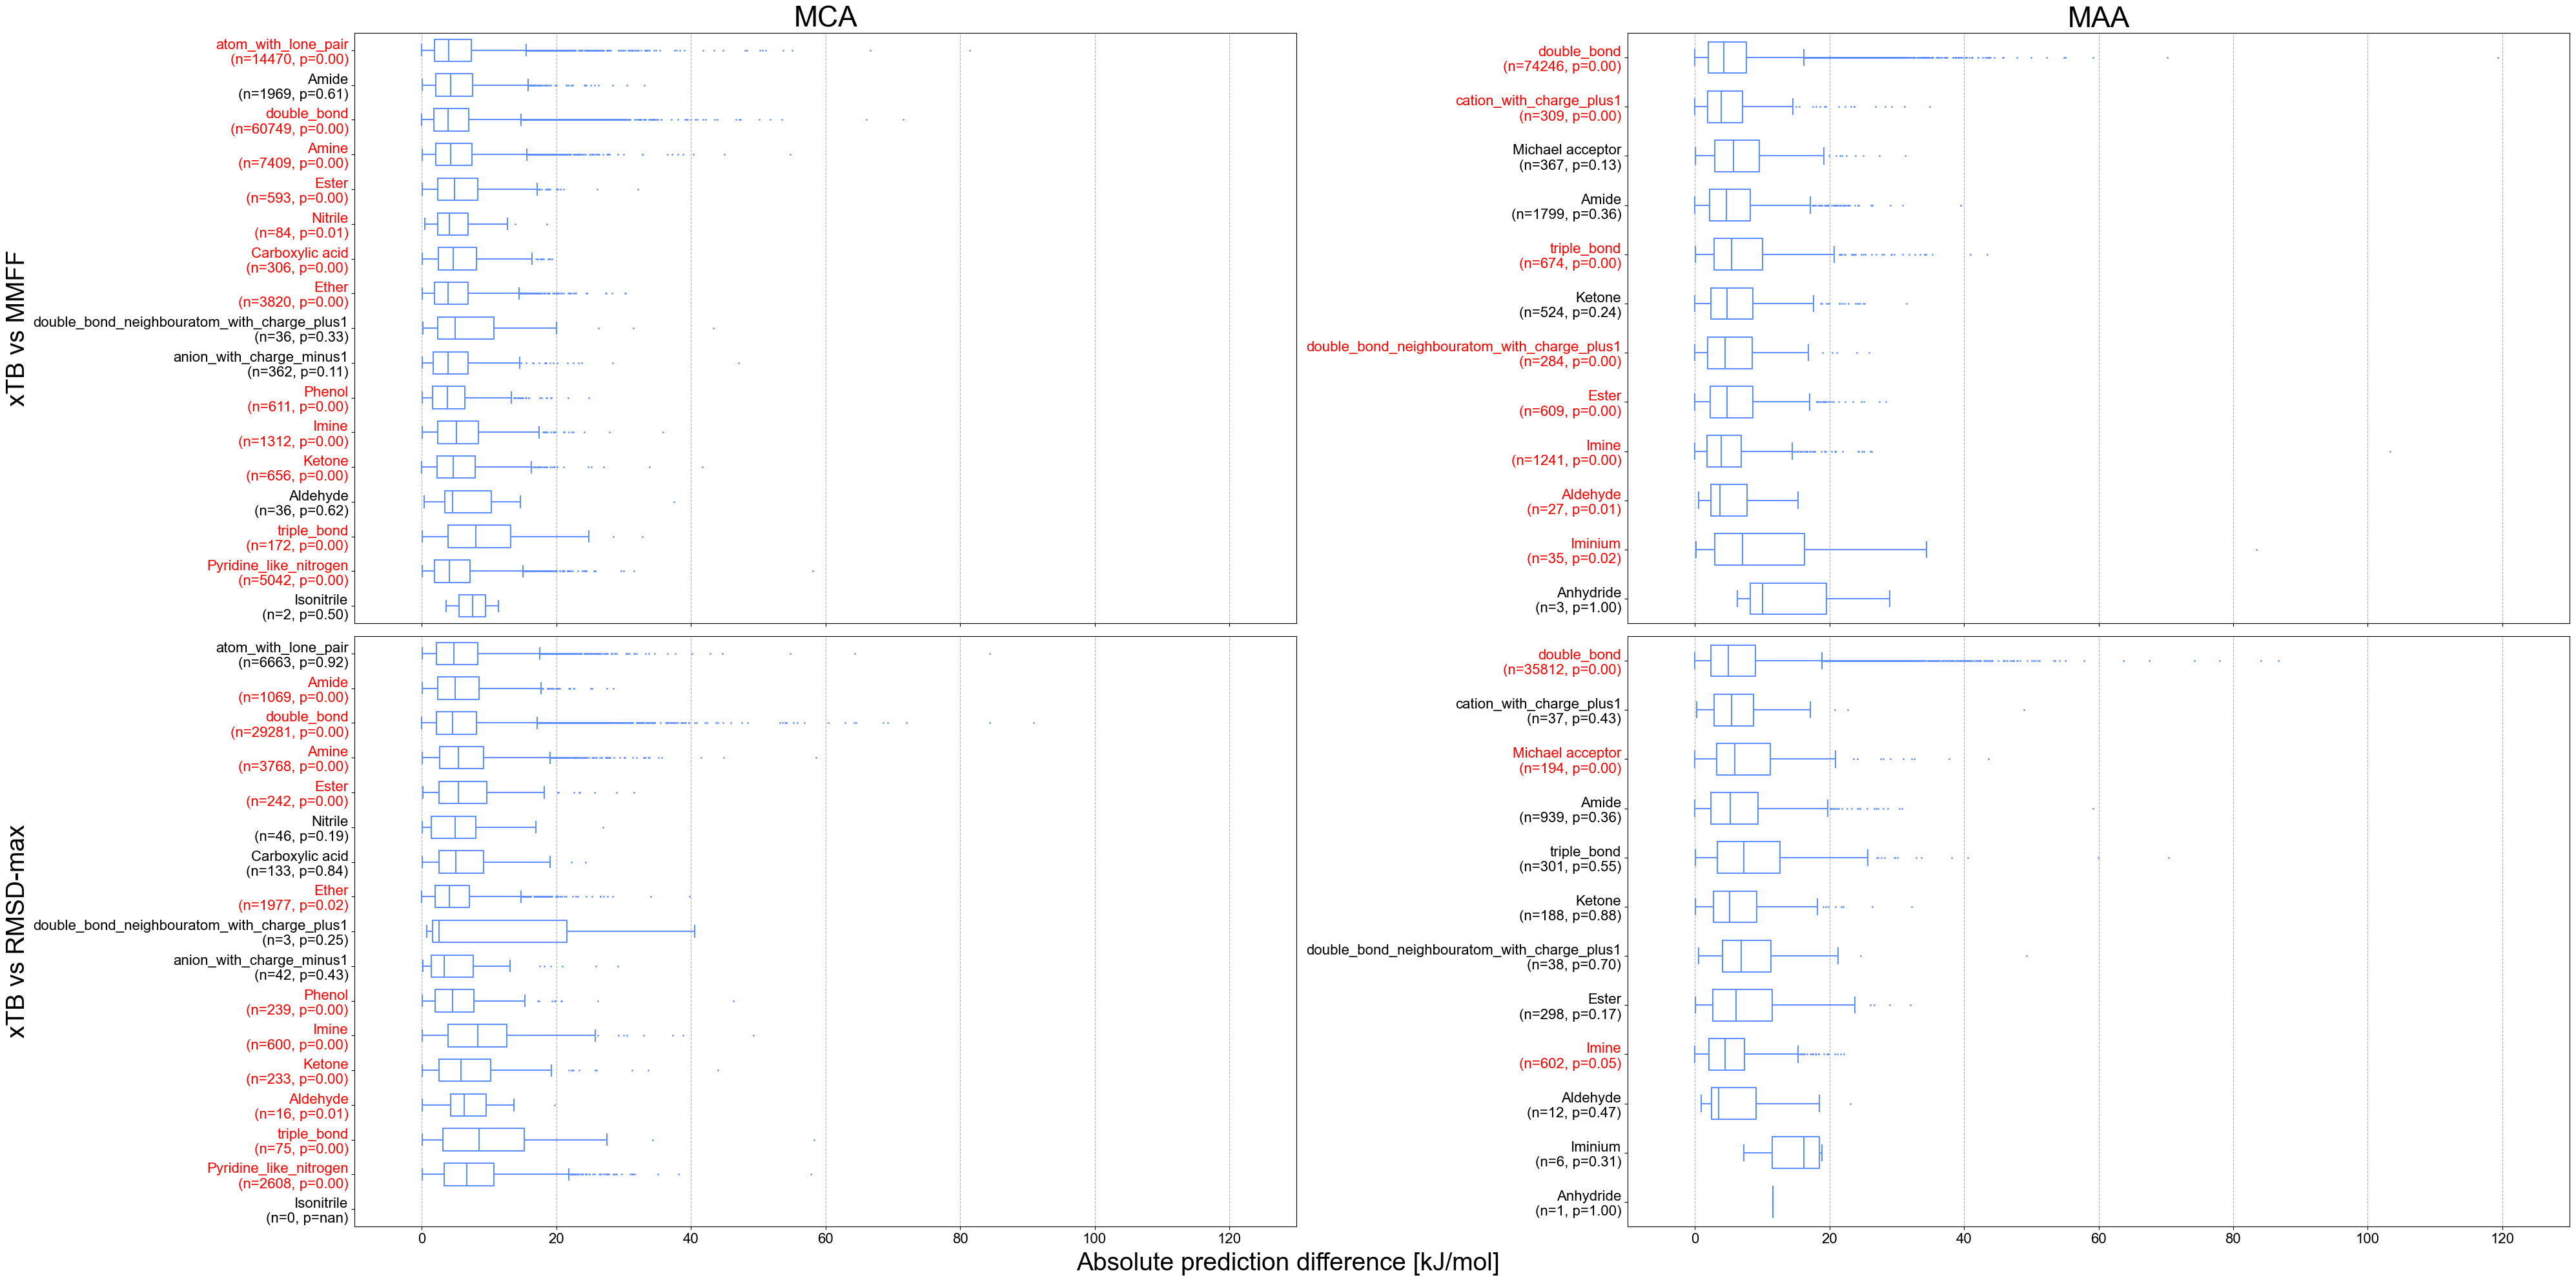

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

from mod_for_analysis import load_csv

plt.rcParams["font.family"] = "Arial"

UNIMOL_COLOR = '#5F8FFF'

ALPHA_SIG = 0.05
BASE_FONT_SIZE = 16

TICKS_FONT_SIZE = int(BASE_FONT_SIZE)
TITLE_FONT_SIZE = int(BASE_FONT_SIZE * 2)
LABEL_FONT_SIZE = int(BASE_FONT_SIZE * 1.8)


def _safe_wilcoxon(x: pd.Series, y: pd.Series) -> float:
    """Return p-value for paired Wilcoxon test; return NaN if not computable."""
    mask = x.notna() & y.notna()
    x2 = x[mask]
    y2 = y[mask]
    if len(x2) == 0:
        return np.nan
    try:
        return wilcoxon(x2, y2).pvalue
    except ValueError:
        # Typical case: all paired differences are zero
        return np.nan


def _build_wide_df(which: str) -> pd.DataFrame:
    """Load base prediction + additional predictions and merge into a wide table."""
    base = load_csv(f'./results/mecap_ref_{which}_layer_0/predictions.csv').copy()
    base = base.rename(columns={"pred": "mmff"})

    xtb = load_csv(f'./results/mecap_ref_{which}_esnuel_orca_layer_0/predictions.csv')[["pred"]].rename(
        columns={"pred": "esnuel_orca"}
    )
    rmsd = load_csv(f'./results/mecap_ref_{which}_rmsd_layer_0/predictions.csv')[["pred"]].rename(
        columns={"pred": "rmsd"}
    )

    wide = pd.concat([base, xtb, rmsd], axis=1)
    return wide


def _build_long_df(wide: pd.DataFrame, axis_target: str) -> pd.DataFrame:
    """Convert wide table to long table for plotting and stats."""
    comparisons = [
        # (left_col, right_col, label)
        ("mmff", "esnuel_orca", "xTB vs MMFF"),
        ("esnuel_orca", "rmsd", "xTB vs RMSD-max"),
    ]

    long_parts = []
    for left_col, right_col, label in comparisons:
        part = wide.copy()
        part["Conformation"] = label
        part["val_left"] = part[left_col]
        part["val_right"] = part[right_col]
        part["abs_diff"] = (part["val_left"] - part["val_right"]).abs()
        long_parts.append(
            part[[axis_target, "Set", "Conformation", "val_left", "val_right", "abs_diff"]]
        )

    long_df = pd.concat(long_parts, ignore_index=True)
    return long_df


def _compute_stats(df_test: pd.DataFrame, axis_target: str) -> pd.DataFrame:
    """Compute n and p-value per (target, Conformation)."""
    def _agg(group: pd.DataFrame) -> pd.Series:
        x = group["val_left"]
        y = group["val_right"]
        mask = x.notna() & y.notna()
        n = int(mask.sum())
        p = _safe_wilcoxon(x, y)
        return pd.Series({"n": n, "p": p})

    stats = (
        df_test
        .groupby([axis_target, "Conformation"], dropna=False)
        .apply(_agg)
        .reset_index()
    )
    return stats


def _plot_one(ax, df_test: pd.DataFrame, stats: pd.DataFrame, axis_target: str, conformation: str, title: str):
    """Shared plotting routine for one axis."""
    # Keep category order stable
    y_order = df_test[axis_target].dropna().unique().tolist()

    data = df_test[df_test["Conformation"] == conformation]

    sns.boxplot(
        data=data,
        y=axis_target,
        x="abs_diff",
        order=y_order,
        ax=ax,
        fill=False,
        color=UNIMOL_COLOR,
        fliersize=1,
        gap=0.2,
    )

    ax.set_xlim((-10, 130))
    ax.grid(visible=True, axis="x", linestyle="--")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(title, fontsize=TITLE_FONT_SIZE)
    ax.tick_params(axis="both", labelsize=TICKS_FONT_SIZE)

    # Build label map and significance map
    sub = stats[stats["Conformation"] == conformation].set_index(axis_target)
    label_map = {}
    sig_map = {}
    for target in y_order:
        if target in sub.index:
            n = sub.loc[target, "n"]
            p = sub.loc[target, "p"]
            if pd.isna(p):
                label_map[target] = f"{target}\n(n={int(n)}, p=nan)"
                sig_map[target] = False
            else:
                label_map[target] = f"{target}\n(n={int(n)}, p={p:.2f})"
                sig_map[target] = (p < ALPHA_SIG)
        else:
            label_map[target] = target
            sig_map[target] = False

    # Apply tick labels and color significant ones
    ax.set_yticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()])
    for t in ax.get_yticklabels():
        base_name = t.get_text().split("\n")[0]
        if sig_map.get(base_name, False):
            t.set_color("red")


def make_box_plots(which: str, ax_top, ax_bottom):
    axis_target = "nuc_names" if "mca" in which else "elec_names"

    wide = _build_wide_df(which)
    long_df = _build_long_df(wide, axis_target)

    df_test = long_df[long_df["Set"] == "Test"].reset_index(drop=True)
    stats = _compute_stats(df_test, axis_target)

    _plot_one(
        ax=ax_top,
        df_test=df_test,
        stats=stats,
        axis_target=axis_target,
        conformation="xTB vs MMFF",
        title=which.upper(),
    )
    _plot_one(
        ax=ax_bottom,
        df_test=df_test,
        stats=stats,
        axis_target=axis_target,
        conformation="xTB vs RMSD-max",
        title=which.upper(),
    )


def main():
    fig, axes = plt.subplots(2, 2, figsize=(40, 20))
    axes = axes.flatten()

    # Left column: MCA, Right column: MAA
    make_box_plots("mca", ax_top=axes[0], ax_bottom=axes[2])
    make_box_plots("maa", ax_top=axes[1], ax_bottom=axes[3])

    axes[0].set_ylabel("xTB vs MMFF", fontsize=LABEL_FONT_SIZE); axes[0].set_xticklabels([])
    axes[1].set_xticklabels([])
    axes[2].set_title(""); axes[2].set_ylabel("xTB vs RMSD-max", fontsize=LABEL_FONT_SIZE)
    axes[3].set_title("")

    fig.supxlabel("Absolute prediction difference [kJ/mol]", fontsize=LABEL_FONT_SIZE)

    fig.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

# Ablation study

In [1]:
'''Statistical table for Reference split'''
import pandas as pd
from mod_for_analysis import load_csv, calculate_stats, extract_best_epoch

mca_dict, maa_dict = {}, {}
ablations = {
    'layer_0': '3D + all atomic features',
    '2d': '2D + all atomic features',
    # 'only_carbon': '3D + replace all atoms to carbons',
    'permuted': '3D + atoms randomized',
}

for suff, key in ablations.items():
    # MCA
    be_ = extract_best_epoch(f'./results/mecap_ref_mca_{suff}/train.log')
    df = load_csv(f'./results/mecap_ref_mca_{suff}/predictions.csv')
    df_test = df[df['Set']=='Test']
    r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
    mca_dict[key] = {
        'best_epoch': be_,
        'r2': r2,
        'r': r,
        'rmse': rmse,
    }

    # MAA
    be_ = extract_best_epoch(f'./results/mecap_ref_maa_{suff}/train.log')
    df = load_csv(f'./results/mecap_ref_maa_{suff}/predictions.csv')
    df_test = df[df['Set']=='Test']
    r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
    maa_dict[key] = {
        'best_epoch': be_,
        'r2': r2,
        'r': r,
        'rmse': rmse,
    }

print('===MCA===')
display(pd.DataFrame(mca_dict).T)

print('===MAA===')
display(pd.DataFrame(maa_dict).T)

===MCA===


,best_epoch,r2,r,rmse
3D + all atomic features,48.0,0.981623,0.991084,9.871353
2D + all atomic features,45.0,0.980177,0.990307,10.252344
3D + atoms randomized,38.0,0.974436,0.987726,11.642764


===MAA===


,best_epoch,r2,r,rmse
3D + all atomic features,48.0,0.976602,0.988392,10.987153
2D + all atomic features,44.0,0.974489,0.987344,11.472659
3D + atoms randomized,44.0,0.968932,0.984905,12.660635


# Case study

In [106]:
import pandas as pd

df_gth_nuc = pd.read_csv('./references/100_rxn_mechanisms/100_rxn_mechanisms_no_error_reactants_calculated_nuc.csv',index_col=0)
df_gth_elec= pd.read_csv('./references/100_rxn_mechanisms/100_rxn_mechanisms_no_error_reactants_calculated_elec.csv',index_col=0)

success_rate_per_mol = []

for df in (df_gth_nuc, df_gth_elec,):
    site_col = 'nuc_sites' if 'nuc_sites' in df else 'elec_sites'
    df['IDENTIFIER'] = [row['reactant_id_no_underbar'] + '_' + str(row[site_col]) for _, row in df.iterrows()]
    df['succeeded']  = [row['reactant_error'] == 'None' and row['product_error'] == 'None' for _, row in df.iterrows()]
    df.set_index('IDENTIFIER',drop=True,inplace=True)
    for gidx, gdf in df.groupby('reactant_id_no_underbar'):
        success_rate_per_mol.append({'Success rate': len(gdf[gdf["succeeded"]]) / len(gdf), 'Site': site_col})

success_rate_per_mol_df = pd.DataFrame(success_rate_per_mol)

Success rate over all sites:
  Nucleophilic -> 0.737
  Electrophilic -> 0.778


/home/iwasaki/miniconda3/envs/unimea_ft/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/iwasaki/miniconda3/envs/unimea_ft/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 18.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Site', ylabel='Success rate'>

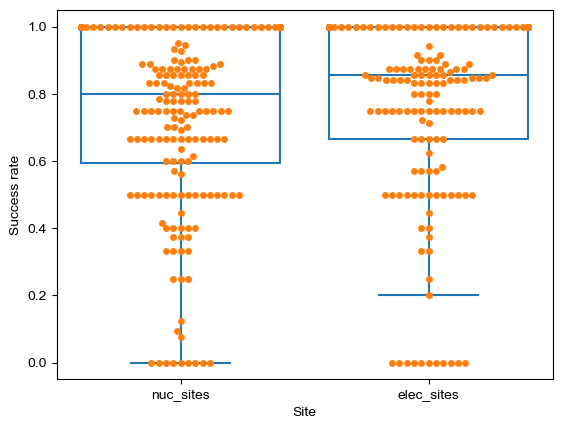

In [107]:
# Calculate and visualize success rate (because some calculation results may not accurate because of connectivity error during the optimization)
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Arial"

print(f'Success rate over all sites:\n'
      f'  Nucleophilic -> {len(df_gth_nuc[df_gth_nuc["succeeded"]]) / len(df_gth_nuc):.3f}\n'
      f'  Electrophilic -> {len(df_gth_elec[df_gth_elec["succeeded"]]) / len(df_gth_elec):.3f}')

sns.boxplot(success_rate_per_mol_df, y='Success rate', x='Site', fill=False, showfliers=False)
sns.swarmplot(success_rate_per_mol_df, y='Success rate', x='Site', size=5)

In [108]:
import pandas as pd

df_pred_mecap_nuc = pd.read_csv('./results/casestudy/100_rxn_mechanisms/mca_v2/predictions.csv')
df_pred_mecap_elec= pd.read_csv('./results/casestudy/100_rxn_mechanisms/maa_v2/predictions.csv')

df_pred_esnml_nuc = pd.read_csv('./references/100_rxn_mechanisms/100_rxn_mechanisms_no_error_reactants_predicted_nuc.csv',index_col=0)
df_pred_esnml_elec= pd.read_csv('./references/100_rxn_mechanisms/100_rxn_mechanisms_no_error_reactants_predicted_elec.csv',index_col=0)

for df in (df_pred_mecap_nuc, df_pred_mecap_elec, df_pred_esnml_nuc, df_pred_esnml_elec,):
    site_col = 'nuc_sites' if 'nuc_sites' in df else 'elec_sites'
    name_col = 'name' if 'name' in df else 'reactant_id_no_underbar'
    df['IDENTIFIER'] = [row[name_col] + '_' + str(row[site_col]) for _, row in df.iterrows()]
    df.set_index('IDENTIFIER',drop=True,inplace=True)
    

In [109]:
df_nuc_all  = pd.concat([df_gth_nuc, df_pred_mecap_nuc[['pred']].rename(columns={'pred': 'mecap'}), df_pred_esnml_nuc[['MCA Value [kJ/mol]']].rename(columns={'MCA Value [kJ/mol]': 'esnuelML'})],axis=1).fillna(False)
df_elec_all = pd.concat([df_gth_elec, df_pred_mecap_elec[['pred']].rename(columns={'pred': 'mecap'}), df_pred_esnml_elec[['MAA Value [kJ/mol]']].rename(columns={'MAA Value [kJ/mol]': 'esnuelML'})],axis=1).fillna(False)

df_nuc_no_error  = df_nuc_all[(df_nuc_all['succeeded']) & (df_nuc_all['mecap']!=False) & (df_nuc_all['esnuelML']!=False)]
df_elec_no_error = df_elec_all[(df_elec_all['succeeded']) & (df_elec_all['mecap']!=False) & (df_elec_all['esnuelML']!=False)]


In [110]:
from scipy.stats import kendalltau

def calculate_kendall_correlation_by_group(df, group_col, col1, col2):
    """
    Calculate Kendall's tau correlation for each group in the dataframe.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe
    group_col : str
        Column name to group by
    col1 : str
        First column for correlation calculation
    col2 : str
        Second column for correlation calculation
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with group names, tau values, and p-values
    """
    results = []
    
    for group_name, group_df in df.groupby(group_col):
        # Remove NaN values
        valid_data = group_df[[col1, col2]].dropna()
        
        if len(valid_data) > 1:  # Need at least 2 points for correlation
            tau, p_value = kendalltau(valid_data[col1], valid_data[col2])
            max_index_match = pd.to_numeric(valid_data[col1], errors='coerce').idxmax() == pd.to_numeric(valid_data[col2], errors='coerce').idxmax()
            results.append({
            group_col: group_name,
            'tau': tau,
            'p_value': p_value,
            'n': len(valid_data),
            'max_index_match': max_index_match,
            })
        else:
            results.append({
            group_col: group_name,
            'tau': None,
            'p_value': None,
            'n': len(valid_data),
            'max_index_match': None,
            })
    res_df = pd.DataFrame(results)
    return res_df.set_index(group_col,drop=True)

df_mecap_nuc_corr  = calculate_kendall_correlation_by_group(df_nuc_no_error, 'reactant_id_no_underbar', 'MCA Value [kJ/mol]', 'mecap')
df_mecap_elec_corr = calculate_kendall_correlation_by_group(df_elec_no_error, 'reactant_id_no_underbar', 'MAA Value [kJ/mol]', 'mecap')

df_esnml_nuc_corr  = calculate_kendall_correlation_by_group(df_nuc_no_error, 'reactant_id_no_underbar', 'MCA Value [kJ/mol]', 'esnuelML')
df_esnml_elec_corr = calculate_kendall_correlation_by_group(df_elec_no_error, 'reactant_id_no_underbar', 'MAA Value [kJ/mol]', 'esnuelML')

df_mecap_nuc_corr['Type'] = 'MCA'; df_mecap_nuc_corr['ML method'] = 'Uni-Mol-MeCAP'
df_mecap_elec_corr['Type'] = 'MAA'; df_mecap_elec_corr['ML method'] = 'Uni-Mol-MeCAP'

df_esnml_nuc_corr['Type'] = 'MCA'; df_esnml_nuc_corr['ML method'] = 'ESNUEL_ML'
df_esnml_elec_corr['Type'] = 'MAA'; df_esnml_elec_corr['ML method'] = 'ESNUEL_ML'

df_to_plot = pd.concat([df_mecap_nuc_corr,df_esnml_nuc_corr,df_mecap_elec_corr,df_esnml_elec_corr]).reset_index()

Top-1 matched rate (Uni-Mol-MeCAP):
  Nucleophilic -> 0.732
  Electrophilic -> 0.704
Top-1 matched rate (ESNUEL_ML):
  Nucleophilic -> 0.659
  Electrophilic -> 0.739


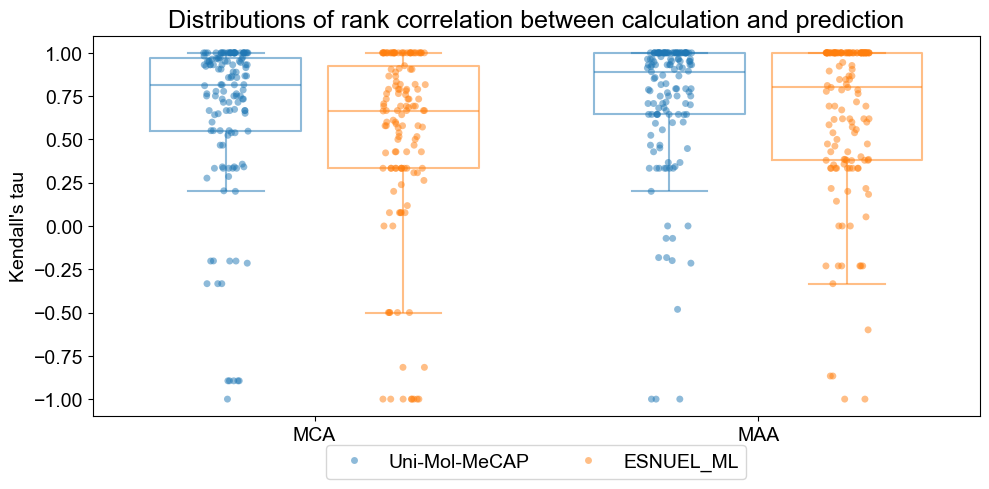

In [140]:
alpha = 0.5
base_font_size = 14

ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)


print(f'Top-1 matched rate (Uni-Mol-MeCAP):\n'
      f'  Nucleophilic -> {len(df_mecap_nuc_corr.dropna(subset=["max_index_match"])[df_mecap_nuc_corr.dropna(subset=["max_index_match"])["max_index_match"]]) / len(df_mecap_nuc_corr.dropna(subset=["max_index_match"])):.3f}\n'
      f'  Electrophilic -> {len(df_mecap_elec_corr.dropna(subset=["max_index_match"])[df_mecap_elec_corr.dropna(subset=["max_index_match"])["max_index_match"]]) / len(df_mecap_elec_corr.dropna(subset=["max_index_match"])):.3f}')

print(f'Top-1 matched rate (ESNUEL_ML):\n'
      f'  Nucleophilic -> {len(df_esnml_nuc_corr.dropna(subset=["max_index_match"])[df_esnml_nuc_corr.dropna(subset=["max_index_match"])["max_index_match"]]) / len(df_esnml_nuc_corr.dropna(subset=["max_index_match"])):.3f}\n'
      f'  Electrophilic -> {len(df_esnml_elec_corr.dropna(subset=["max_index_match"])[df_esnml_elec_corr.dropna(subset=["max_index_match"])["max_index_match"]]) / len(df_esnml_elec_corr.dropna(subset=["max_index_match"])):.3f}')

plt.figure(figsize=(10, 5))

sns.boxplot(
      df_to_plot,
      y='tau',
      x='Type',
      hue='ML method',
      fill=False,
      gap=0.15,
      showfliers=False,
      legend=False,
      boxprops={'alpha': alpha},
      whiskerprops={'alpha': alpha},
      capprops={'alpha': alpha},
      medianprops={'alpha': alpha},
)
sns.stripplot(df_to_plot, y='tau', x='Type', hue='ML method', dodge=True, alpha=alpha, size=5)

plt.tick_params(axis='both', labelsize=ticks_font_size)
plt.xlabel('')
plt.ylabel("Kendall's tau",fontsize=ticks_font_size)
plt.title('Distributions of rank correlation between calculation and prediction',fontsize=title_font_size)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=ticks_font_size)
plt.tight_layout()

In [171]:
from rdkit import Chem

mapno_order = {}

for key, df in {'source': df_gth_nuc, 'sink': df_gth_elec,}.items():
    pred_col = 'MCA Value [kJ/mol]' if key=='source' else 'MAA Value [kJ/mol]'
    site_col = 'nuc_sites' if key=='source' else 'elec_sites'
    df['MapNum'] = df.apply(lambda row: Chem.MolFromSmiles(row['reactant_smi']).GetAtomWithIdx(row[site_col]).GetAtomMapNum(), axis=1)
    df['rxn_id'] = df['reactant_id_no_underbar'].apply(lambda s: int(s.split('reac')[0]))
    for gidx, gdf in df.groupby('rxn_id'):
        if not gdf['succeeded'].all(): continue
        gdf_sorted = gdf.sort_values(pred_col,ascending=False)
        if gidx not in mapno_order:
            mapno_order[gidx] = {'esnuel': {key: {int(row['MapNum']): idx / (len(gdf) - 1) for idx, (_, row) in enumerate(gdf_sorted.iterrows()) if row['MapNum'] != 0}}}
        else:
            mapno_order[gidx]['esnuel'][key] = {int(row['MapNum']): idx / (len(gdf) - 1) for idx, (_, row) in enumerate(gdf_sorted.iterrows()) if row['MapNum'] != 0}

for key, df in {'source': df_pred_mecap_nuc, 'sink': df_pred_mecap_elec,}.items():
    site_col = 'nuc_sites' if key=='source' else 'elec_sites'
    df['MapNum'] = df.apply(lambda row: Chem.MolFromSmiles(row['smiles']).GetAtomWithIdx(row[site_col]).GetAtomMapNum(), axis=1)
    df['rxn_id'] = df['name'].apply(lambda s: int(s.split('reac')[0]))
    for gidx, gdf in df.groupby('rxn_id'):
        gdf_sorted = gdf.sort_values('pred',ascending=False)
        if gidx not in mapno_order:
            mapno_order[gidx] = {'mecap': {key: {int(row['MapNum']): idx / (len(gdf) - 1) for idx, (_, row) in enumerate(gdf_sorted.iterrows()) if row['MapNum'] != 0}}}
        elif 'mecap' not in mapno_order[gidx]:
            mapno_order[gidx]['mecap'] = {key: {int(row['MapNum']): idx / (len(gdf) - 1) for idx, (_, row) in enumerate(gdf_sorted.iterrows()) if row['MapNum'] != 0}}
        else:
            mapno_order[gidx]['mecap'][key] = {int(row['MapNum']): idx / (len(gdf) - 1) for idx, (_, row) in enumerate(gdf_sorted.iterrows()) if row['MapNum'] != 0}

for key, df in {'source': df_pred_esnml_nuc, 'sink': df_pred_esnml_elec,}.items():
    pred_col = 'MCA Value [kJ/mol]' if key=='source' else 'MAA Value [kJ/mol]'
    site_col = 'nuc_sites' if key=='source' else 'elec_sites'
    df['MapNum'] = df.apply(lambda row: Chem.MolFromSmiles(row['reactant_smi']).GetAtomWithIdx(row[site_col]).GetAtomMapNum(), axis=1)
    df['rxn_id'] = df['reactant_id_no_underbar'].apply(lambda s: int(s.split('reac')[0]))
    for gidx, gdf in df.groupby('rxn_id'):
        gdf_sorted = gdf.sort_values(pred_col,ascending=False)
        if 'esnuelML' not in mapno_order[gidx]:
            mapno_order[gidx]['esnuelML'] = {key: {int(row['MapNum']): idx / (len(gdf) - 1) for idx, (_, row) in enumerate(gdf_sorted.iterrows()) if row['MapNum'] != 0}}
        else:
            mapno_order[gidx]['esnuelML'][key] = {int(row['MapNum']): idx / (len(gdf) - 1) for idx, (_, row) in enumerate(gdf_sorted.iterrows()) if row['MapNum'] != 0}

df_rxn = pd.read_csv('./references/100_rxn_mechanisms/100_rxn_mechanisms_no_error.csv',index_col=0)
df_rxn['esnuel_source_order'] = None; df_rxn['esnuel_sink_order'] = None
df_rxn['mecap_source_order'] = None; df_rxn['mecap_sink_order'] = None
df_rxn['esnuelML_source_order'] = None; df_rxn['esnuelML_sink_order'] = None

for ridx, rords_ in mapno_order.items():
    for model, rords in rords_.items():
        for key, rord in rords.items():
            for mnum, mord in rord.items():
                if df_rxn.loc[ridx, key] == mnum:
                    df_rxn.loc[ridx, f'{model}_' + key + '_order'] = mord


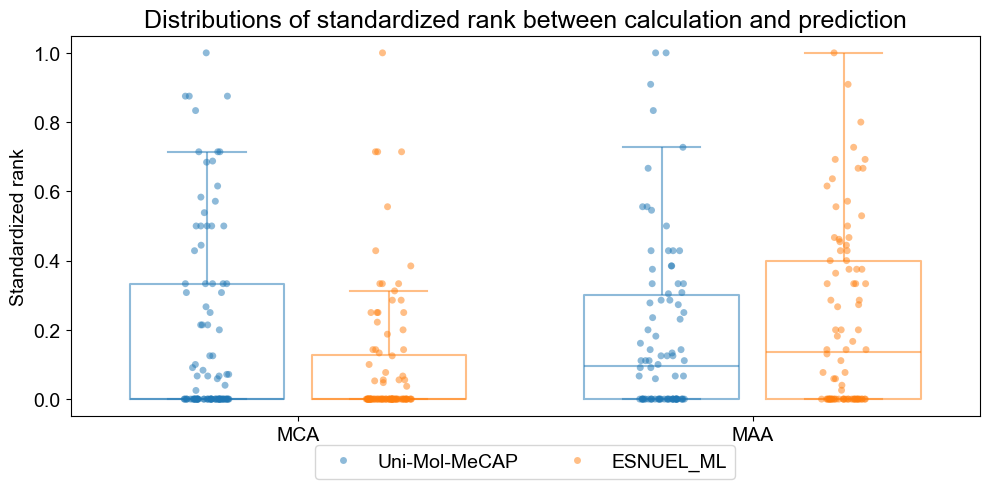

In [175]:
alpha = 0.5
base_font_size = 14

ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)

cols_to_plot = {
    'mecap_source_order': ('Uni-Mol-MeCAP', 'MCA'),
    'mecap_sink_order': ('Uni-Mol-MeCAP', 'MAA'),
    'esnuelML_source_order': ('ESNUEL_ML', 'MCA'),
    'esnuelML_sink_order': ('ESNUEL_ML', 'MAA'),
}
df_to_plot = None

for col_n, props in cols_to_plot.items():
    orders = df_rxn[[col_n]].rename(columns={col_n: 'Standardized rank'})
    orders['Model'] = props[0]
    orders['Type'] = props[1]
    df_to_plot = orders if df_to_plot is None else pd.concat([df_to_plot, orders])

df_to_plot.reset_index(inplace=True)

plt.figure(figsize=(10, 5))

sns.boxplot(
      df_to_plot,
      y='Standardized rank',
      x='Type',
      hue='Model',
      fill=False,
      gap=0.15,
      showfliers=False,
      legend=False,
      boxprops={'alpha': alpha},
      whiskerprops={'alpha': alpha},
      capprops={'alpha': alpha},
      medianprops={'alpha': alpha},
)
sns.stripplot(df_to_plot, y='Standardized rank', x='Type', hue='Model', dodge=True, alpha=alpha, size=5)

plt.tick_params(axis='both', labelsize=ticks_font_size)
plt.xlabel('')
plt.ylabel("Standardized rank",fontsize=ticks_font_size)
plt.title('Distributions of standardized rank between calculation and prediction',fontsize=title_font_size)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=ticks_font_size)
plt.tight_layout()

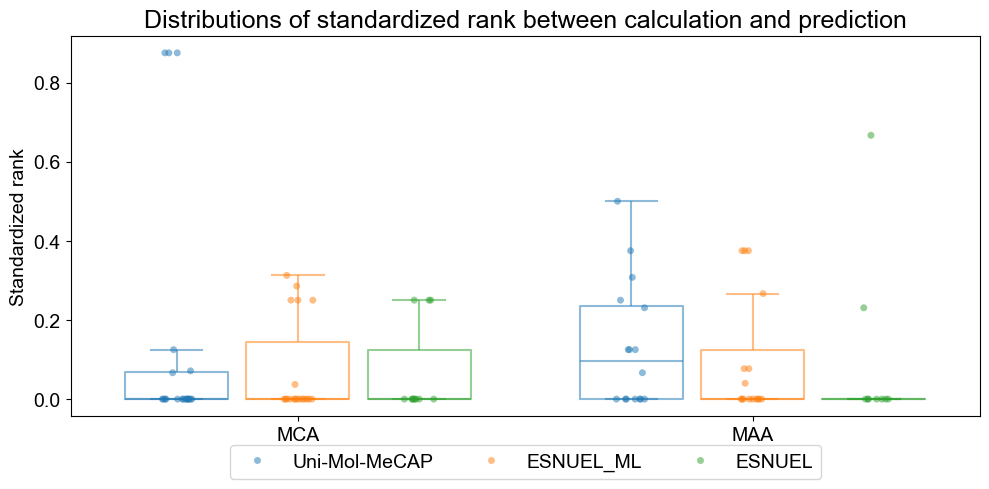

In [178]:
alpha = 0.5
base_font_size = 14

ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)

cols_to_plot = {
    'mecap_source_order': ('Uni-Mol-MeCAP', 'MCA'),
    'mecap_sink_order': ('Uni-Mol-MeCAP', 'MAA'),
    'esnuelML_source_order': ('ESNUEL_ML', 'MCA'),
    'esnuelML_sink_order': ('ESNUEL_ML', 'MAA'),
    'esnuel_source_order': ('ESNUEL', 'MCA'),
    'esnuel_sink_order': ('ESNUEL', 'MAA'),
}
df_to_plot = None

df_rxn_drop = df_rxn.dropna(subset=['esnuel_source_order','esnuel_sink_order'],how='all')

for col_n, props in cols_to_plot.items():
    orders = df_rxn_drop[[col_n]].rename(columns={col_n: 'Standardized rank'})
    orders['Model'] = props[0]
    orders['Type'] = props[1]
    df_to_plot = orders if df_to_plot is None else pd.concat([df_to_plot, orders])

df_to_plot.reset_index(inplace=True)

plt.figure(figsize=(10, 5))

sns.boxplot(
      df_to_plot,
      y='Standardized rank',
      x='Type',
      hue='Model',
      fill=False,
      gap=0.15,
      showfliers=False,
      legend=False,
      boxprops={'alpha': alpha},
      whiskerprops={'alpha': alpha},
      capprops={'alpha': alpha},
      medianprops={'alpha': alpha},
)
sns.stripplot(df_to_plot, y='Standardized rank', x='Type', hue='Model', dodge=True, alpha=alpha, size=5)

plt.tick_params(axis='both', labelsize=ticks_font_size)
plt.xlabel('')
plt.ylabel("Standardized rank",fontsize=ticks_font_size)
plt.title('Distributions of standardized rank between calculation and prediction',fontsize=title_font_size)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=ticks_font_size)
plt.tight_layout()